# Data Preprocessing and Data Alignment

**Environment Setup and Library Imports**

In [ ]:
%pip install ultralytics #Colab command to install the Ultralytics library used for YOLOv8 model training
import os # Functions for interacting with the file system, such as checking whether a file exists
import shutil #used for copying, moving, or deleting folder trees
import random # Used to shuffle data or select random samples, preventing the model from learning based on file order
import yaml #allows Python to read and write YAML files, which YOLO uses to define dataset paths and class names
import cv2 #library for image and video processing (reading,images,resizing and drawing bounding boxes)
import pandas as pd #analysis using tables
import numpy as np #for numerical computing for arrays and matrices
import matplotlib.pyplot as plt #for plotting and visualisation, such as training loss graph
from pathlib import Path #a way to handle file system paths
from ultralytics import YOLO #imports the main class used to load train and run predictions with YOLO models
from sklearn.model_selection import GroupKFold #a ML tool for cross validation
from sklearn.model_selection import StratifiedGroupKFold #for stratified CV
from google.colab import drive #allows mounting of the Google Drive to access or save datasets
from sklearn.model_selection import GroupShuffleSplit #splits data into train and test sets keeps groups together
import matplotlib.image as mpimg #visualisation tool to manipulate image files like jpg
from tabulate import tabulate #tables in a visually appealing way
from matplotlib.lines import Line2D #2D line graph library
from collections import defaultdict #key error prevention, creates key if not there
from tqdm.auto import tqdm #progress bars library
import matplotlib.pyplot as mpimg #used to read and load image files so they can be displayed in the plots
from google.colab import files #specific google colab tool to enable files download from the cloud to the local computer
import json  # Saves nested cross-validation results and selected hyperparameters as JSON files


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Google Drive Mounting and Project Directory Setup**

In [ ]:
drive.mount('/content/drive') #Mounts Google Drive to allow project files and trained models to be saved persistently
project_folder = Path("/content/drive/MyDrive/capillary_CV_project") #creates a path with pathlib library of where the project resides "capillary_CV_project"
project_folder.mkdir(parents=True, exist_ok=True) # Creates the project folder on Google Drive if it does not already exist

Mounted at /content/drive


**Dataset Extraction, Normalisation, and Pairing**

* Extracts data from the raw zip file.
* Matches corresponding YOLO labels (.txt files) to extracted video frames (.jpg files).
* Normalises filenames to ensure accurate pairing.
* Outputs the final count of paired frames and unique videos.

In [ ]:
#Defines the raw-data location, project directory and output folder
zip_path = '/content/drive/MyDrive/dataset_raw 6.zip'
project_folder = Path('/content/drive/MyDrive/capillary_CV_project')
cleaned_area = project_folder / "cleaned_dataset"

#Initialises a clean workspace by purging existing data to ensure experimental reproducibility and prevent file contamination
if cleaned_area.exists(): shutil.rmtree(cleaned_area)
cleaned_area.mkdir(parents=True, exist_ok=True)

# Extracts raw data to the local runtime for high-speed and indexes all image and label paths for processing
!unzip -o -q "$zip_path" -d /content/temporary_extract

all_jpgs = []
all_txts = []

for root, dirs, files in os.walk('/content/temporary_extract'):
    if '__MACOSX' in root: continue
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg')):
            all_jpgs.append(os.path.join(root, file))
        elif file.lower().endswith('.txt'):
            all_txts.append(os.path.join(root, file))

#Standardises filenames by removing special characters and spaces to facilitate accurate matching between images and their corresponding label files
def normalize(name):
    return name.replace(" ", "").replace("_", "").replace("-", "").lower()

#Executes a matching loop to pair images with labels based on their normalised filenames
paired_data = []

for img_path in all_jpgs:
    img_name = os.path.basename(img_path)
    img_real = os.path.splitext(img_name)[0]
    normalised_img = normalize(img_real)

    match = None
    for text_path in all_txts:
        text_name = os.path.basename(text_path)
        text_real = os.path.splitext(text_name)[0]
        normalised_text = normalize(text_real)


        if normalised_text.endswith(normalised_img):
            match = text_path
            break
#If a pair is validated: standardises filenames, consolidates files into the cleaned directory, and extracts Video ID metadata for group-based data splitting
    if match:
        clean_name = img_real.replace(" ", "_")

        if '_f' in clean_name.lower():
            video_id = clean_name.split('_f')[0]
        else:
            video_id = 'randomvideo'

        shutil.copy(img_path, cleaned_area / (clean_name + ".jpg"))
        shutil.copy(match, cleaned_area / (clean_name + ".txt"))

        paired_data.append({'img': clean_name + ".jpg", 'video_id': video_id})

#Generates a metadata audit to confirm the final count of paired frames and unique source video
if not paired_data:
    print("no match")
else:
    df = pd.DataFrame(paired_data)

    df = df.drop_duplicates(subset=['img'])

    df.to_csv(project_folder / "metadata.csv", index=False)
    print(f"Paired images: {len(df)}")
    print(f"Unique videos: {df['video_id'].nunique()}")

Paired images: 612
Unique videos: 11


**Dataset Annotation & Frame Summary**

* Parses YOLO label files to quantify the total number of frames and individual capillary annotations.
* Outputs a breakdown of frames and annotations per unique video, informing the subsequent train/validation/test split.

In [ ]:
# --- Summarise Frames and Annotations per Video ---
print("Breakdown per Video")

# Initialise a dictionary to keep track of annotations per video
# Keys are unique video IDs from the 'video_id' column, and values start at 0
annotations_per_video = {video_id: 0 for video_id in df['video_id'].unique()}

# Counter variable to keep track of every single annotation found across the entire dataset
total_capillaries = 0

# Calculate the frequency of frames associated with each video
# This tells you the total number of frames (rows) associated with each video_id
frames_per_video = df['video_id'].value_counts()

# Loop through the dataframe to count annotations per file and add them to the video totals
for index, row in df.iterrows():
    # Extracts the video ID and the image filename from the current row being processed
    video_id = row['video_id']
    img_name = row['img']

    # Converts the image filename (e.g., .jpg) to a text filename (e.g., .txt) for YOLO labels
    txt_name = img_name.replace('.jpg', '.txt')

    # Combines the directory path with the filename to create the full path to the label
    txt_path = cleaned_area / txt_name

    # Checks if the annotation file actually exists at that path before trying to open it
    if txt_path.exists():
        # Opens the text file in read mode ('r')
        with open(txt_path, 'r') as file:
            # Reads all lines and ignores empty ones; each line represents one annotated object
            annotations = [line for line in file.readlines() if line.strip()]

            # Counts how many valid lines (annotations/capillaries) were found in this specific file
            num_annotations = len(annotations)

            # Add to this specific video's running total in the dictionary
            annotations_per_video[video_id] += num_annotations

            # Add to the grand total for the entire project
            total_capillaries += num_annotations

# Loop through the frame counts and print results side-by-side with annotation counts
for video_name, frame_count in frames_per_video.items():
    # Retrieves the specific annotation total for this video from the dictionary
    anno_count = annotations_per_video.get(video_name, 0)
    print(f"Video: {video_name} | Frames: {frame_count} | Annotations: {anno_count}")

# Print the final grand total of all annotated capillaries across all processed files
print(f"\nTotal capillaries annotated across all matched files: {total_capillaries}")

Breakdown per Video
Video: -20260325_104600 | Frames: 66 | Annotations: 2565
Video: -20260325_105749 | Frames: 62 | Annotations: 2634
Video: videos_nov_-20250813_145858 | Frames: 60 | Annotations: 680
Video: videos_nov_-20250813_145244 | Frames: 60 | Annotations: 1942
Video: videos_nov_-20250813_140442 | Frames: 60 | Annotations: 1691
Video: videos_nov_-20250813_140205 | Frames: 58 | Annotations: 1396
Video: videos_nov_-20250813_144801 | Frames: 55 | Annotations: 1251
Video: videos_nov_-20250813_145708 | Frames: 54 | Annotations: 597
Video: -20260325_110212 | Frames: 53 | Annotations: 1859
Video: videos_nov_-20250813_141040 | Frames: 49 | Annotations: 594
Video: videos_nov_-20250813_140702 | Frames: 35 | Annotations: 363

Total capillaries annotated across all matched files: 15572


# Final Model Training: 80/10/10 Data Split, Training and Performance analysis

**Final Data splitting**

-  80% for Training: This portion of the data is used to teach the model what capillaries look like and how to detect them.

-   10% for Validation: Used during the training process to monitor the model's performance and prevent overfitting. It helps in tuning hyperparameters and selecting the best model configuration.

-   10% for Test Set: This is a completely unseen video (or set of frames from a unique video) that the model has never encountered during training or validation. It is used to provide an unbiased evaluation of how well the model generalises to new, real-world data.

-   Grouping by Video ID: To prevent the model from memorising specific frames, if one frame from a video is assigned to the test or validation set, all other frames from that same video are also placed in that set. This ensures that the model learns to identify capillaries in *new* videos, rather than just recognising familiar frames.

-   Training Set (Train): The primary dataset the model 'studies' to learn the features and patterns of capillaries.

-  Validation Set (Val): A subset of data used during training to assess model performance at regular intervals, guiding adjustments and preventing the model from becoming too specific to the training data.

-   Test Set (Test): A held-out, independent dataset used *only* after training is complete to give an unbiased grade on the model's real-world performance.

In [ ]:
# Set paths
#Defines the location for the final organised dataset
final_split = project_folder / 'final_80_10_10_split'
#If the folder already exists, delete it to ensure a clean start without old files
if final_split.exists():
    shutil.rmtree(final_split)

#Loads the CSV file that maps individual frames to their parent video IDs
df = pd.read_csv(project_folder / "metadata.csv")


# Manually partition videos to achieve an approximate 80/10/10 split while ensuring no data leakage; this prevents the model from seeing frames of the same video in different sets

# Test set: Assignment of a video ~9.5% of total data
test_vids = ['videos_nov_-20250813_140205']

# Validation set: The 62-frame video (~10.1%)
val_vids = ['-20260325_105749']

# Training set: All other videos (~80.4%)
train_vids = [
    '-20260325_104600',
    'videos_nov_-20250813_145244',
    'videos_nov_-20250813_145858',
    'videos_nov_-20250813_140442',
    'videos_nov_-20250813_144801',
    'videos_nov_-20250813_145708',
    '-20260325_110212',
    'videos_nov_-20250813_141040',
    'videos_nov_-20250813_140702'
]
# --------------------------------------------

# Create the dataframes for training, validation and testing
df_train = df[df['video_id'].isin(train_vids)]
df_val = df[df['video_id'].isin(val_vids)]
df_test = df[df['video_id'].isin(test_vids)]

#Loop through each set to create the directory structure and copy files
for stage, data in zip(['train', 'val', 'test'], [df_train, df_val, df_test]):
  #Creates YOLO formatted subdirectories
    (final_split / stage / 'images').mkdir(parents=True, exist_ok=True)
    (final_split / stage / 'labels').mkdir(parents=True, exist_ok=True)

    print(f"Processing {stage} set: {len(data)} images...")
#Iterates through every frame assigned to this specific set
    for _, row in data.iterrows():
      #Extracts the filename without the extension to find the corresponding .txt label
        img_name = row['img']
        base_name = img_name.rsplit('.', 1)[0]

        #Copies the image from the source "cleaned_area" to the new destination
        shutil.copy(cleaned_area / img_name, final_split / stage / 'images' / img_name)
        #Copies the label file; assumes labels have the same base name as images
        shutil.copy(cleaned_area / (base_name + ".txt"), final_split / stage / 'labels' / (base_name + ".txt"))

#Defines the configuration dictionary required by YOLOv8
yaml_content = {
    'path': str(final_split.absolute()),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['capillary']
}
#Saves the dictionary as a .yaml file so the YOLO model knows where to find the data
with open(final_split / 'data.yaml', 'w') as f:
    yaml.dump(yaml_content, f)

print(f"\nSplit Complete!")
print(f"Train: {len(df_train)} frames | Val: {len(df_val)} frames | Test: {len(df_test)} frames")

Processing train set: 492 images...
Processing val set: 62 images...
Processing test set: 58 images...

Split Complete!
Train: 492 frames | Val: 62 frames | Test: 58 frames


**Model Training for Full Dataset Training**

* Trains the YOLOv8 Nano model on the 80/10/10 partitioned dataset.
* Initialises the model with pre-trained weights and configures key hyperparameters (epochs, image size, batch size, optimiser).
* Saves training logs, final weights, and performance charts to the project directory.

In [ ]:

# Initialises the YOLOv8 Nano model using pre-trained weights as a starting point
model = YOLO("yolov8n.pt")

model.train(
    # Points the trainer to the 80/10/10 data map created in the previous step
    data=str(final_split / "data.yaml"),
    # Sets the total training iteration
    epochs=150,
    # Sets the image resolution to 1280 pixels to better see tiny capillaries
    imgsz=1280,
    # Number of images processed at once; 8 balances memory and stability
    batch=8,
    # Stops training early if mAP doesn't improve for 30 consecutive epochs
    patience=30,
    # Uses the AdamW optimiser, which is excellent for handling weight decay
    optimizer="AdamW",
    # Initial learning rate; lowered to 5e-4 to prevent overshooting the solution
    lr0=5e-4,
    # Final learning rate factor; ensures the model "settles" into a stable state
    lrf=0.1,
    # Penalty for large weights; increased to 1e-2 to prevent overfitting
    weight_decay=1e-2,
    # Slowly increases the learning rate for the first 5 epochs to prevent "shocks"
    warmup_epochs=5,
    # Heavily weights the "box" loss to prioritise perfectly drawing the capillary outlines
    box=7.5,
    # Weight for classification; lower because the task only has one class (capillary)
    cls=0.5,
    # Distribution Focal Loss; helps the model refine the edges of the boxes
    dfl=1.5,
    # Combines 4 images into 1; 0.5 means it happens half the time to boost variety
    mosaic=0.5,
    # Mixup augmentation; kept at 0.0 to avoid blurring the delicate capillary textures
    mixup=0.0,
    # Disables mosaic for the last 20 epochs to let the model train on "clean" images
    close_mosaic=20,
    # The directory where all logs, weights, and charts will be saved
    project=str(project_folder / "runs"),
    # The specific name for this final training run folder
    name="final_80_10_10_stabilised",
    # Allows the cell to be re-run without error if the folder already exists
    exist_ok=True
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/capillary_CV_project/final_80_10_10_split/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=final_80_10_10_stabilised, nbs=64, nms=False, opset=None

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78e17bcd36e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

**Performance Visualisation after training: Metric smoothing and Values**

* Displays the standard YOLO results collage, detailing training/validation losses, precision, recall, and mAP metrics across all epochs.
* Generates smoothed plots (using a moving average) for loss, precision, recall, and mAP@50 to reduce noise and highlight true learning trends.
* Outputs a final performance summary table utilising data from the "best epoch," detailing key metrics (mAP, Precision, Recall, F1-score) and their biological relevance.

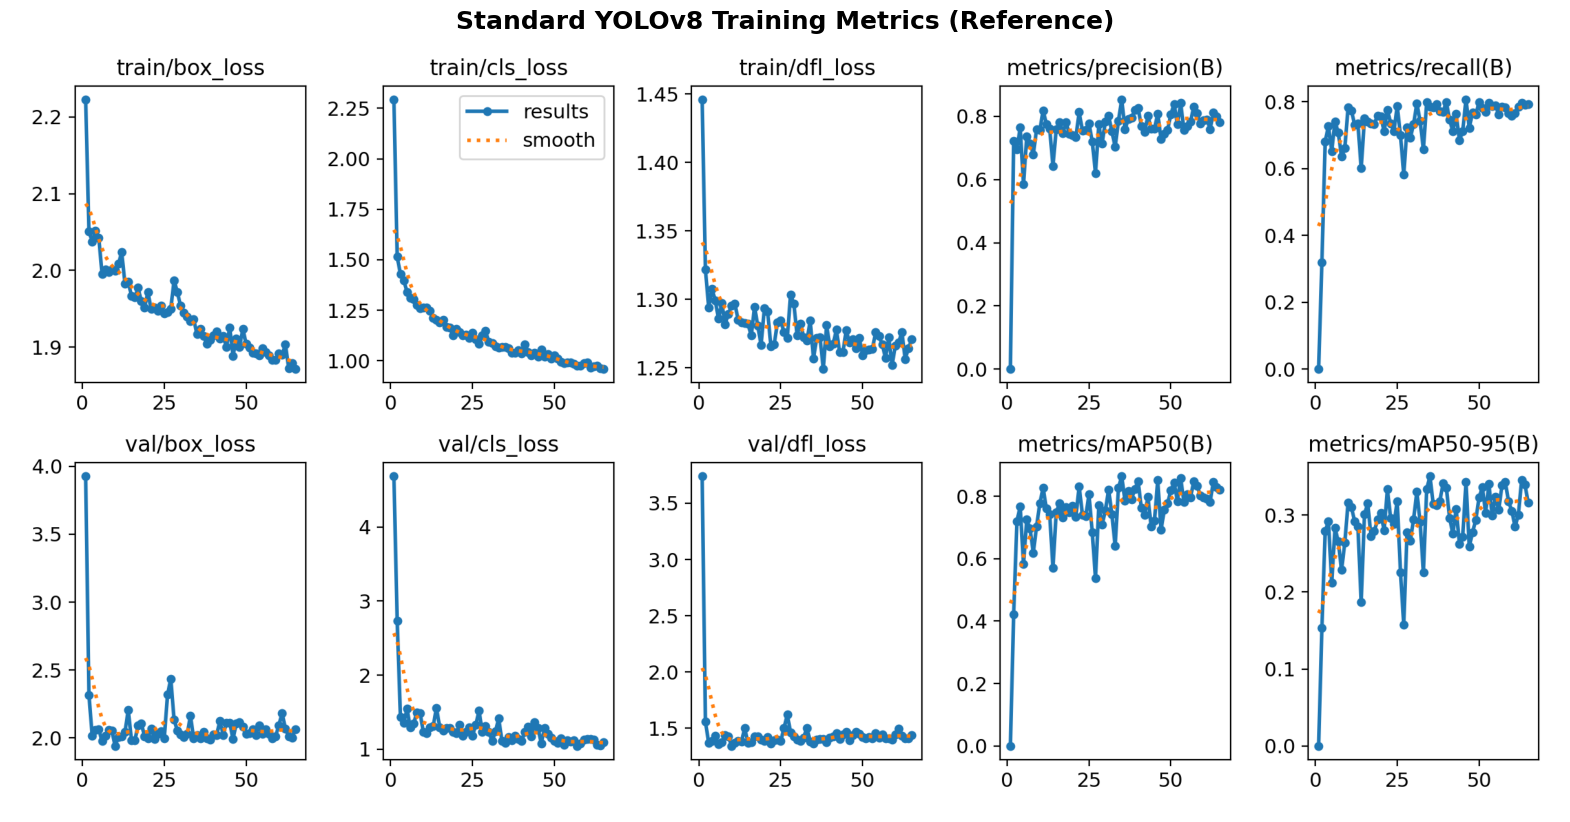


--- GENERATING OVERLAY LOSS ANALYSIS (SMOOTHED) ---


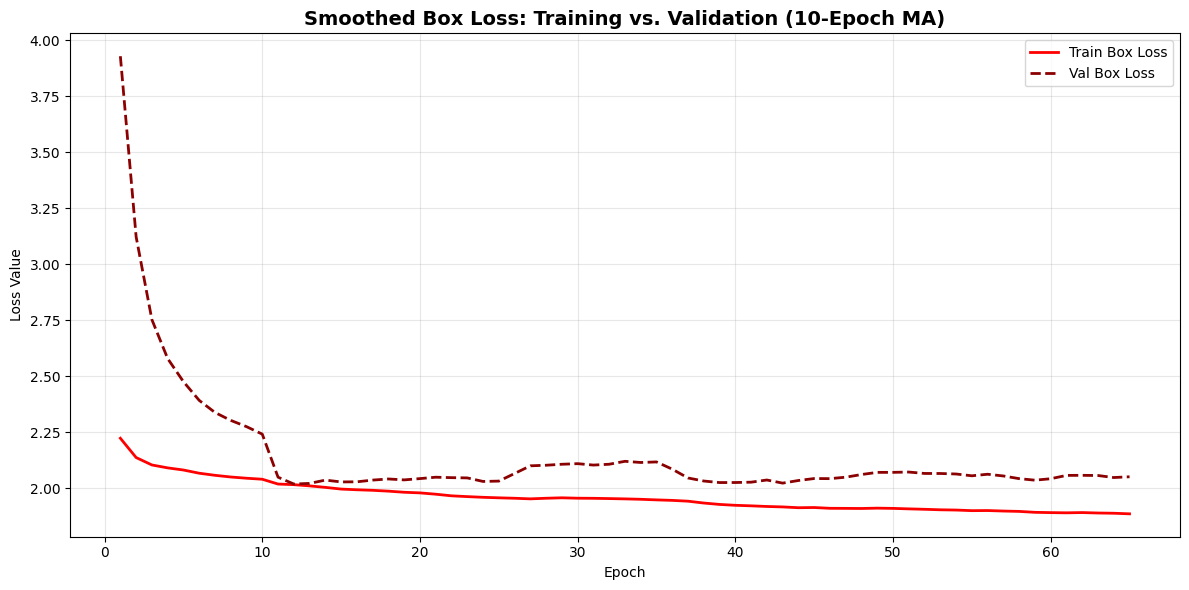

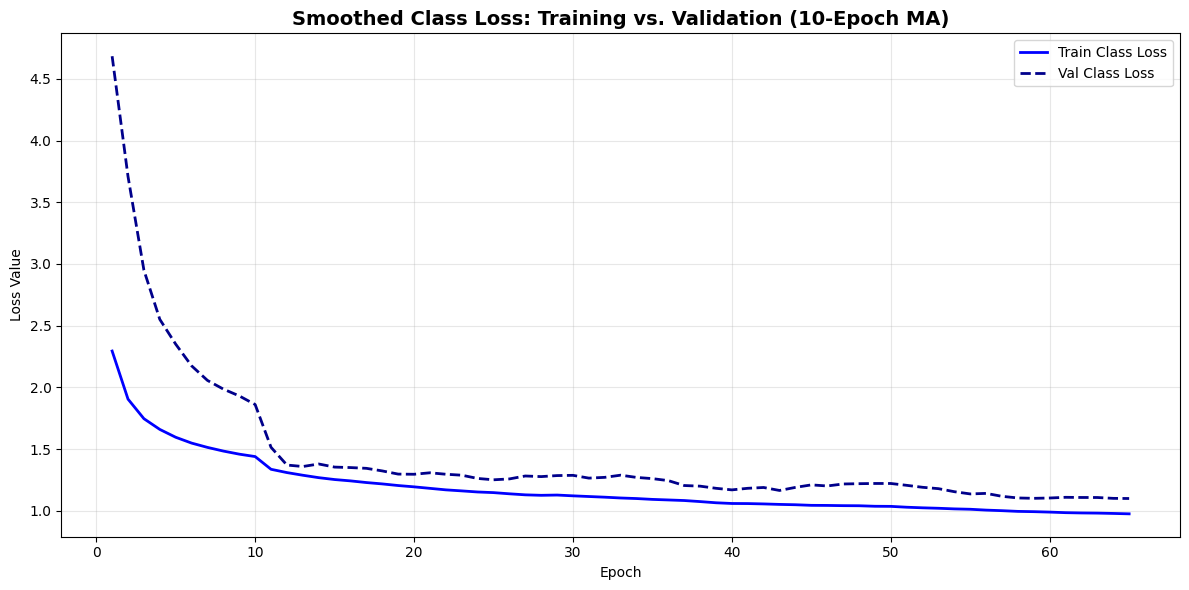

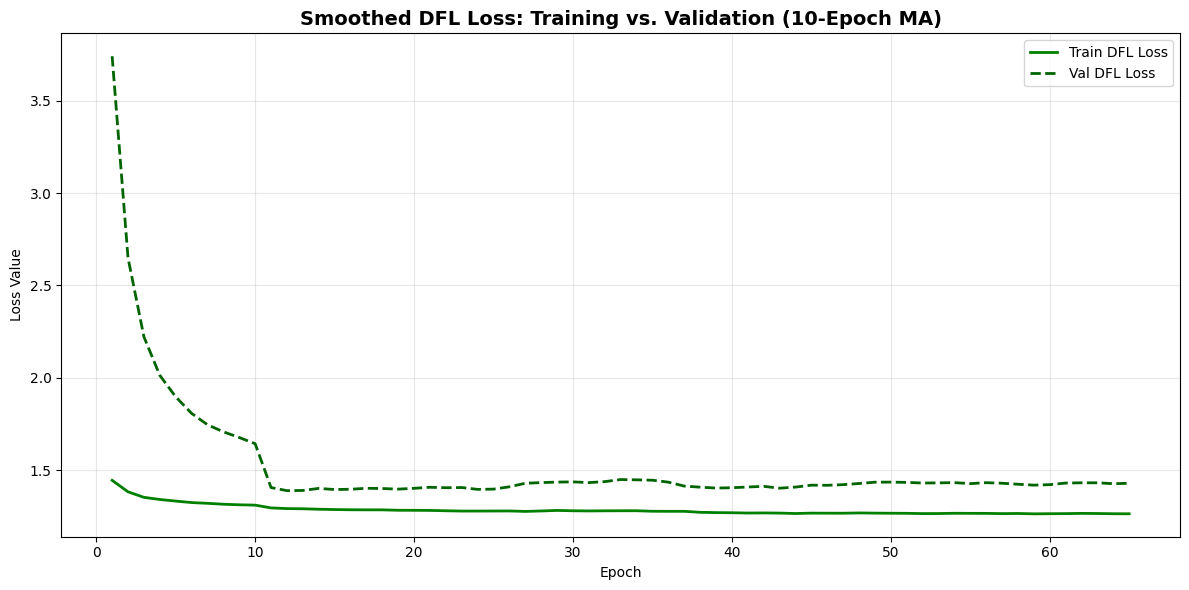


--- GENERATING INDIVIDUAL METRIC ANALYSIS (SMOOTHED ONLY) ---


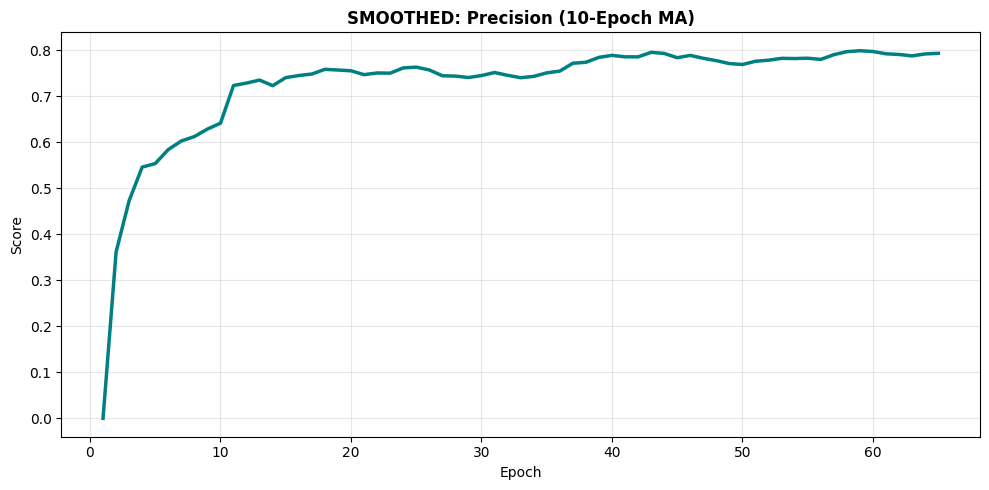

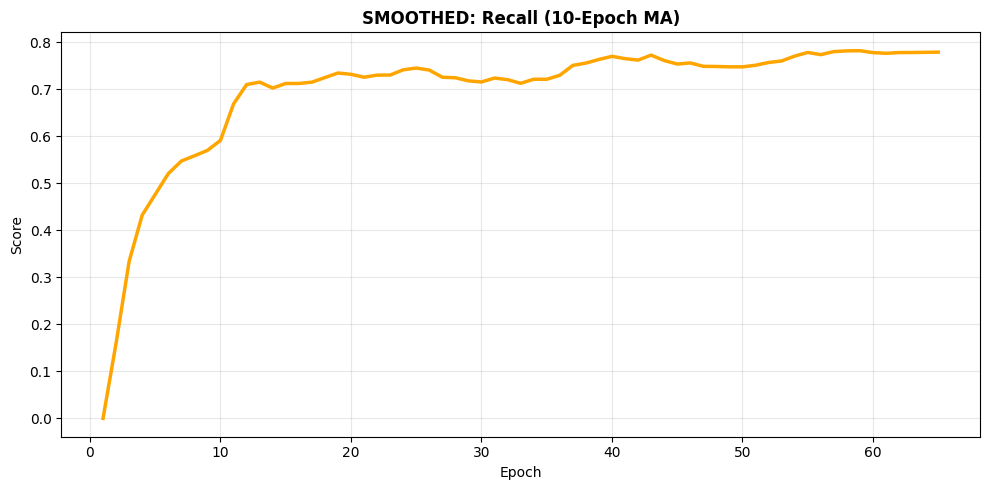

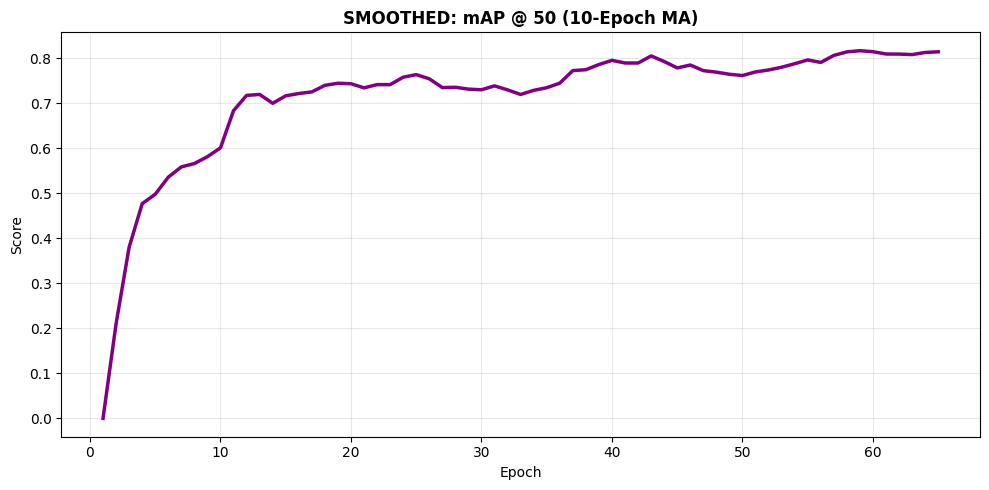

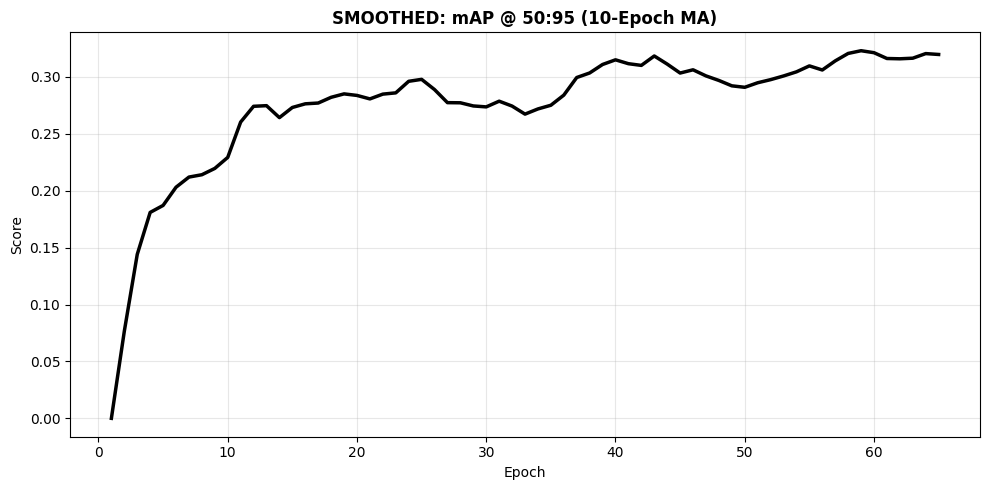

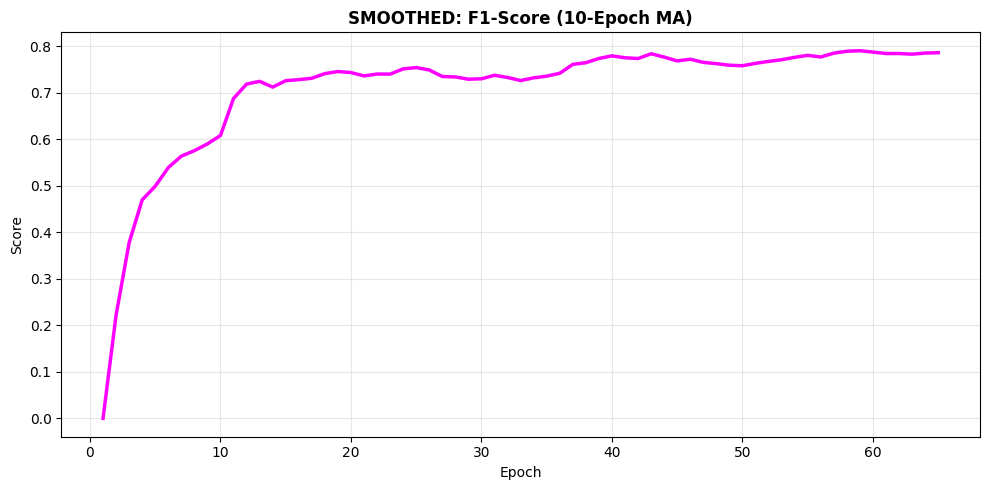


═════════════════════════════════════════════════════════════════════════════════════
             FINAL MODEL PERFORMANCE SUMMARY (PEAK AT EPOCH 35)             
═════════════════════════════════════════════════════════════════════════════════════
╒══════════════════════╤═════════╤════════════════════════════════════════════════════════╕
│ Performance Metric   │   Value │ Biological Study Impact                                │
╞══════════════════════╪═════════╪════════════════════════════════════════════════════════╡
│ mAP @ 50             │  0.8641 │ Top model performance at 50% overlap threshold         │
├──────────────────────┼─────────┼────────────────────────────────────────────────────────┤
│ mAP @ 50:95          │  0.3505 │ Rigorous average across 10 IoU thresholds (0.50:0.95)  │
├──────────────────────┼─────────┼────────────────────────────────────────────────────────┤
│ F1-Score             │  0.8187 │ Harmonic balance between Precision and Recall          │
├─────────────

In [ ]:

# --- DISPLAY OFFICIAL YOLO RESULTS COLLAGE ---
#Locates the default graphic collage generated by YOLO contains loss and metric charts
results_path = project_folder / "runs/final_80_10_10_stabilised/results.png"

if results_path.exists():
    img = mpimg.imread(results_path)
    plt.figure(figsize=(20, 12))
    plt.imshow(img)
    #Displays the official image as a reference before generating custom plots
    plt.axis('off')
    plt.title("Standard YOLOv8 Training Metrics (Reference)", fontsize=18, fontweight='bold')
    plt.show()
else:
    print("Warning: results.png collage not found.")

# --- LOAD DATA & CALCULATE SMOOTHED METRICS ---
csv_path = project_folder / "runs/final_80_10_10_stabilised/results.csv"

if csv_path.exists():
    results_df = pd.read_csv(csv_path)
    results_df.columns = [c.strip() for c in results_df.columns]

    # Calculate F1 for internal validation
    results_df['metrics/f1'] = 2 * (results_df['metrics/precision(B)'] * results_df['metrics/recall(B)']) / \
                                  (results_df['metrics/precision(B)'] + results_df['metrics/recall(B)'] + 1e-9)

    # Smoothing Setup (10-epoch Moving Average) to remove jitter from the graphs
    window = 10
    smooth_df = results_df.rolling(window=window, min_periods=1).mean()
    # Ensure epoch stays as the original integer sequence for the X-axis
    smooth_df['epoch'] = results_df['epoch']

    # --- GENERATE OVERLAY LOSS PLOTS (TRAIN VS VAL) ---
    # This helps visualise convergence and gap between training/validation to monitor for overfitting
    print("\n--- GENERATING OVERLAY LOSS ANALYSIS (SMOOTHED) ---")
    loss_pairs = [
        ('box_loss', 'Box Loss', 'red', 'darkred'),
        ('cls_loss', 'Class Loss', 'blue', 'darkblue'),
        ('dfl_loss', 'DFL Loss', 'green', 'darkgreen')
    ]

    for suffix, label, t_color, v_color in loss_pairs:
      #Plots training as a solid line and validation as a dashed line for comparison
        plt.figure(figsize=(12, 6))
        plt.plot(smooth_df['epoch'], smooth_df[f'train/{suffix}'], color=t_color, linewidth=2, label=f'Train {label}')
        plt.plot(smooth_df['epoch'], smooth_df[f'val/{suffix}'], color=v_color, linewidth=2, linestyle='--', label=f'Val {label}')
        plt.title(f"Smoothed {label}: Training vs. Validation ({window}-Epoch MA)", fontweight='bold', fontsize=14)
        plt.xlabel("Epoch")
        plt.ylabel("Loss Value")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # --- GENERATE INDIVIDUAL SMOOTHED METRIC PLOTS ---
 # Visualise core object detection metrics (mAP, Precision, Recall) using smoothed data for clearer performance interpretation
    metrics_to_plot = [
        ('metrics/precision(B)', 'Precision', 'teal'),
        ('metrics/recall(B)', 'Recall', 'orange'),
        ('metrics/mAP50(B)', 'mAP @ 50', 'purple'),
        ('metrics/mAP50-95(B)', 'mAP @ 50:95', 'black'),
        ('metrics/f1', 'F1-Score', 'magenta'),

    ]

    print("\n--- GENERATING INDIVIDUAL METRIC ANALYSIS (SMOOTHED ONLY) ---")
    for col, title, color in metrics_to_plot:
        plt.figure(figsize=(10, 5))
        plt.plot(smooth_df['epoch'], smooth_df[col], color=color, linewidth=2.5)
        plt.title(f"SMOOTHED: {title} ({window}-Epoch MA)", fontweight='bold')
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # --- PROFESSIONAL PERFORMANCE TABLE ---
    # Identifies the epoch with peak mAP@50 and summarises final loss
    best_idx = results_df['metrics/mAP50(B)'].idxmax()
    best_row = results_df.loc[best_idx]
    #Captures the very last epoch's loss for comparison
    final_row = results_df.iloc[-1]
#Prepares a clean data structure for the final results table
    metrics_table = [
        ["mAP @ 50", f"{best_row['metrics/mAP50(B)']:.4f}", "Top model performance at 50% overlap threshold"],
        ["mAP @ 50:95", f"{best_row['metrics/mAP50-95(B)']:.4f}", "Rigorous average across 10 IoU thresholds (0.50:0.95)"],
        ["F1-Score", f"{best_row['metrics/f1']:.4f}", "Harmonic balance between Precision and Recall"],
        ["Precision", f"{best_row['metrics/precision(B)']:.4f}", "Exactness: Proportion of AI boxes that were real"],
        ["Recall", f"{best_row['metrics/recall(B)']:.4f}", "Completeness: Proportion of total capillaries detected"],
        ["Final Train Box Loss", f"{final_row['train/box_loss']:.4f}", "Localisation error in the training dataset"],
        ["Final Val Box Loss", f"{final_row['val/box_loss']:.4f}", "Localisation error in the validation dataset"]
    ]
#Prints a high-quality summary table for inclusion in documentation or presentations
    print("\n" + "═"*85)
    print(f"             FINAL MODEL PERFORMANCE SUMMARY (PEAK AT EPOCH {int(best_row['epoch'])})             ")
    print("═"*85)
    print(tabulate(metrics_table, headers=["Performance Metric", "Value", "Biological Study Impact"], tablefmt="fancy_grid"))
    print("═"*85)

else:
    print("Error: results.csv not found at the specified path. Ensure the training folder structure is correct.")

# Test Set Evaluation and Error Diagnostics


**Confidence Threshold Sensitivity Analysis**

* Loads the best-performing YOLOv8 model weights from the final stabilised training run.
* Defines a sweep of confidence levels while keeping the Intersection over Union (IoU) fixed, isolating the impact of sensitivity on model performance.
* Iterates through each confidence level, evaluating the model against the unbiased held-out test set to calculate precision, recall, and F1-score.
* Generates a trade-off visualisation to empirically identify the optimal confidence threshold that maximises the harmonic balance (F1-score) between detecting true capillaries and minimising false positives.


--- STARTING CONFIDENCE SWEEP (Fixed IoU: 0.5) ---
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 28.3±4.4 MB/s, size: 39.0 KB)
val: Scanning /content/drive/MyDrive/capillary_CV_project/final_80_10_10_split/test/labels... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 214.6it/s 0.3s
val: New cache created: /content/drive/MyDrive/capillary_CV_project/final_80_10_10_split/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6it/s 1.5s
                   all         58       1396       0.81      0.845      0.823      0.284
Speed: 2.1ms preprocess, 10.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Conf 0.10: P=0.8103, R=0.8446, F1=0.8271
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fas

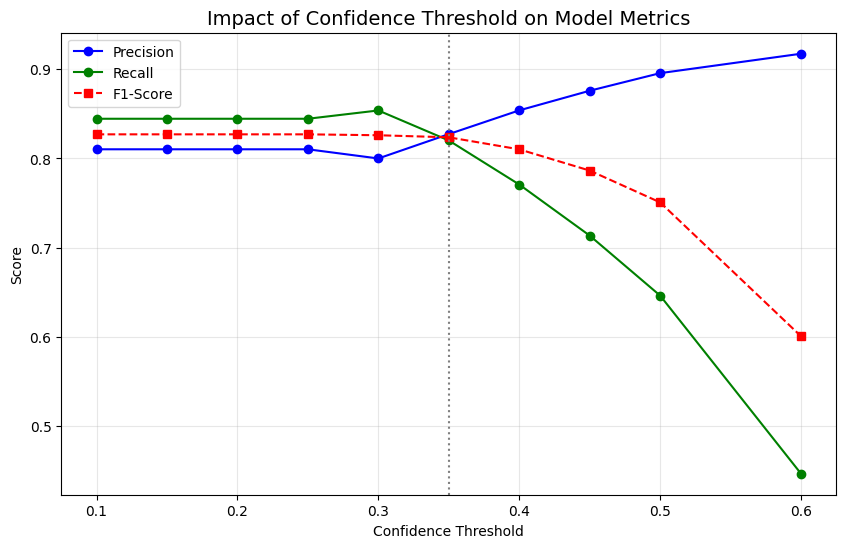


════════════════════════════════════════
HIGHEST F1 CONFIDENCE: 0.10
Max F1-Score: 0.8271
════════════════════════════════════════


In [ ]:

#Loads the specific weights from the final stabilised training run
best_model = YOLO(project_folder / "runs/final_80_10_10_stabilised/weights/best.pt")

#Setup Parameters
#Defines a range of sensitivity levels to test from very loose to very strict
conf_levels = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.6]
#Keeps the intersection over union fixed at 50% to isolate the confidence
fixed_iou = 0.50
sweep_results = []

print(f"--- STARTING CONFIDENCE SWEEP (Fixed IoU: {fixed_iou}) ---")

# Run the Sweep
#Iterates through each confidence level and evaluates the model against the test split
for conf in conf_levels:
    metrics = best_model.val(
        data=str(final_split / "data.yaml"),
        split='test', #Uses the holdout test set for an unbiased evaluation
        conf=conf,
        iou=fixed_iou,
        plots=False, #Disables plot generation to speed up the loop
        verbose=False
    )

    # Extract metrics from the YOLO results object
    p = metrics.box.mp   # Precision: how many detections were actually capillaries
    r = metrics.box.mr   # Recall: how many total capillaries did the AI find
    f1 = 2 * (p * r) / (p + r + 1e-9) #harmonic balance between precision and recall


#Stores the results in a list for later conversion into a table
    sweep_results.append({
        'Threshold': conf,
        'Precision': p,
        'Recall': r,
        'F1_Score': f1
    })
    print(f"Conf {conf:.2f}: P={p:.4f}, R={r:.4f}, F1={f1:.4f}")

# Process Results
#Converts the list of dictionaries into a structured DataFrame for easy plotting
df_sweep = pd.DataFrame(sweep_results)

# Plot the Trade-off
#Visualise the Precision-Recall trade-off; as the threshold tightens, false positives decrease but missed detections increase
plt.figure(figsize=(10, 6))
plt.plot(df_sweep['Threshold'], df_sweep['Precision'], label='Precision', marker='o', color='blue')
plt.plot(df_sweep['Threshold'], df_sweep['Recall'], label='Recall', marker='o', color='green')
plt.plot(df_sweep['Threshold'], df_sweep['F1_Score'], label='F1-Score', marker='s', color='red', linestyle='--')

plt.title('Impact of Confidence Threshold on Model Metrics', fontsize=14)
plt.xlabel('Confidence Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
# Adds a visual marker for the selected operating threshold to support comparison
plt.axvline(x=0.35, color='gray', linestyle=':', label='Selected threshold (0.35)')
plt.show()

#Final Recommendation
#Automatically identifies the threshold that yielded the absolute highest F1-Score
best_row = df_sweep.loc[df_sweep['F1_Score'].idxmax()]
print("\n" + "═"*40)
print(f"HIGHEST F1 CONFIDENCE: {best_row['Threshold']:.2f}")
print(f"Max F1-Score: {best_row['F1_Score']:.4f}")
print("═"*40)


**Official Test Set Performance Evaluation and Visualisation**

* Loads the optimal YOLOv8 model weights obtained from the final stabilised training run.
* Executes a validation pass on the independent holdout test set using optimised thresholds (Conf: 0.35, IoU: 0.50) to generate finalised performance metrics.
* Extracts and calculates primary detection metrics, including mAP@50, Precision, Recall, and the F1-Score, to quantify model efficacy.
* Generates a professional performance report summarising the detection capabilities of the model.
* Visualises and exports diagnostic plots, such as the Confusion Matrix and Precision-Recall curves, to analyse classification and localisation performance.

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 23.3±2.8 MB/s, size: 39.0 KB)
val: Scanning /content/drive/MyDrive/capillary_CV_project/final_80_10_10_split/test/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 11.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5s/it 5.9s
                   all         58       1396      0.827       0.82      0.754      0.262
Speed: 10.7ms preprocess, 10.9ms inference, 0.0ms loss, 28.6ms postprocess per image
Results saved to /content/runs/detect/val-26

═══════════════════════════════════════════════════════════════════════════
             OFFICIAL TEST SET PERFORMANCE REPORT (CONF: 0.35)             
═══════════════════════════════════════════════════════════════════════════
╒═══════

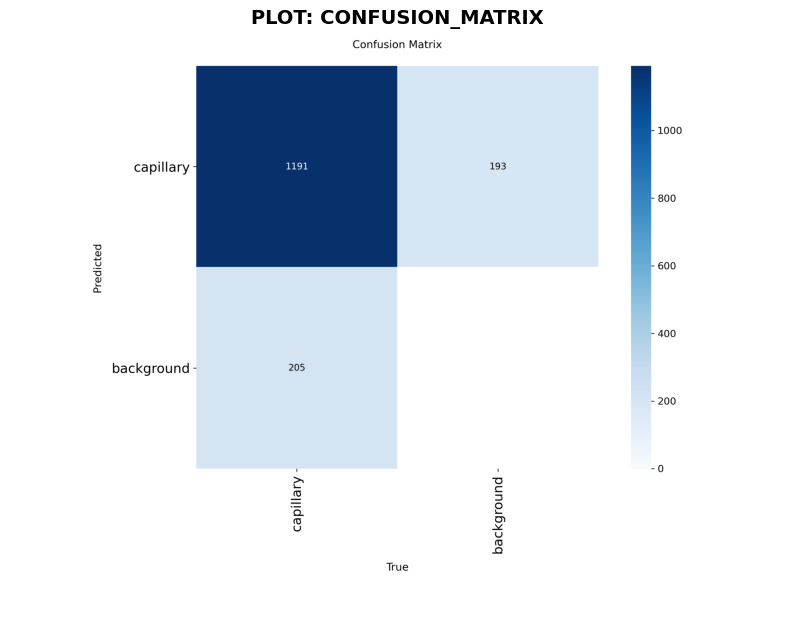

In [ ]:
#Load the model
# Load the optimised weights representing the model state with the highest validation performance
best_model = YOLO(project_folder / "runs/final_80_10_10_stabilised/weights/best.pt") # Initialises the YOLO model using best-performing weights

#Run validation on the test split at confidence threshold 0.35
# Performs evaluation on the holdout test set to provide an unbiased estimate of real-world generalisation
test_metrics = best_model.val(
    data=str(final_split / "data.yaml"),
    split='test',
    # These parameters were selected based on the results of the confidence threshold sweep giving the most balanced Precision and Recall
    conf=0.35,
    iou=0.50,
    plots=True # Automatically generates the F1, Precision, and Recall graphs
)

# Extract and Calculate All Official Metrics
mp = test_metrics.box.mp          # Precision from validation results
mr = test_metrics.box.mr          # Recall from validation results
map50 = test_metrics.box.map50    # mAP@50 (Mean Average Precision at 0.50 IoU)
map95 = test_metrics.box.map      # mAP@50-95 (Average precision across IoU thresholds)
f1_score = 2 * (mp * mr) / (mp + mr + 1e-9) # F1-score: Harmonic mean of precision and recall


#PRINT THE TABLE (Professional Formatting)
# Organises the results into a structured list for clear, professional output
stats_table = [
    ["mAP@50", f"{map50:.4f}", "Mean Average Precision at 50% IoU"],
    ["mAP@50-95", f"{map95:.4f}", "Precision averaged over multiple IoU thresholds"],
    ["Precision", f"{mp:.4f}", "Exactness: % of AI detections that were correct"],
    ["Recall", f"{mr:.4f}", "Completeness: % of actual capillaries successfully found"],
    ["F1-Score", f"{f1_score:.4f}", "The balanced score between Precision and Recall"],
]

print("\n" + "═"*75)
print("             OFFICIAL TEST SET PERFORMANCE REPORT (CONF: 0.35)             ")
print("═"*75)
print(tabulate(stats_table, headers=["Metric", "Value", "Description"], tablefmt="fancy_grid"))
print("═"*75 + "\n")

#Display the Validation Curves and Confusion Matrix
# Retrieves the directory where YOLO saved the diagnostic performance plots
plot_dir = test_metrics.save_dir
target_plots = ["F1_curve.png", "P_curve.png", "R_curve.png", "confusion_matrix.png"]

print("--- GENERATING PERFORMANCE CURVES ---")
# Loops through the target files and displays them directly in the notebook
for plot_name in target_plots:
    path = os.path.join(plot_dir, plot_name)
    if os.path.exists(path):
        plt.figure(figsize=(10, 8))
        img = mpimg.imread(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"PLOT: {plot_name.replace('.png', '').upper()}", fontsize=14, fontweight='bold')
        plt.show() # Renders F1, Precision, Recall, and Confusion Matrix plots

**Visualising Model Predictions vs. Ground Truth**

* **Threshold Synchronisation**: Automatically applies the most balanced confidence threshold derived from the sensitivity analysis to ensure consistency in visualisation.
* **Frame Selection**: Identifies a representative sample from the holdout test set to demonstrate model performance on unseen data.
* **Comparative Inference**: Executes a side-by-side comparison between manual annotations (Ground Truth) and AI-generated bounding boxes.
* **Spatial Validation**: Provides qualitative evidence of the model’s ability to accurately localise dorsum-finger capillaries, supporting the quantitative metrics reported in the performance tables.

Scanning 58 images for the best frame at exactly 0.35 confidence...
Optimal Frame Selected: videos_nov_-20250813_140205_f01020.jpg (Rank: 1, Count Difference: 0)


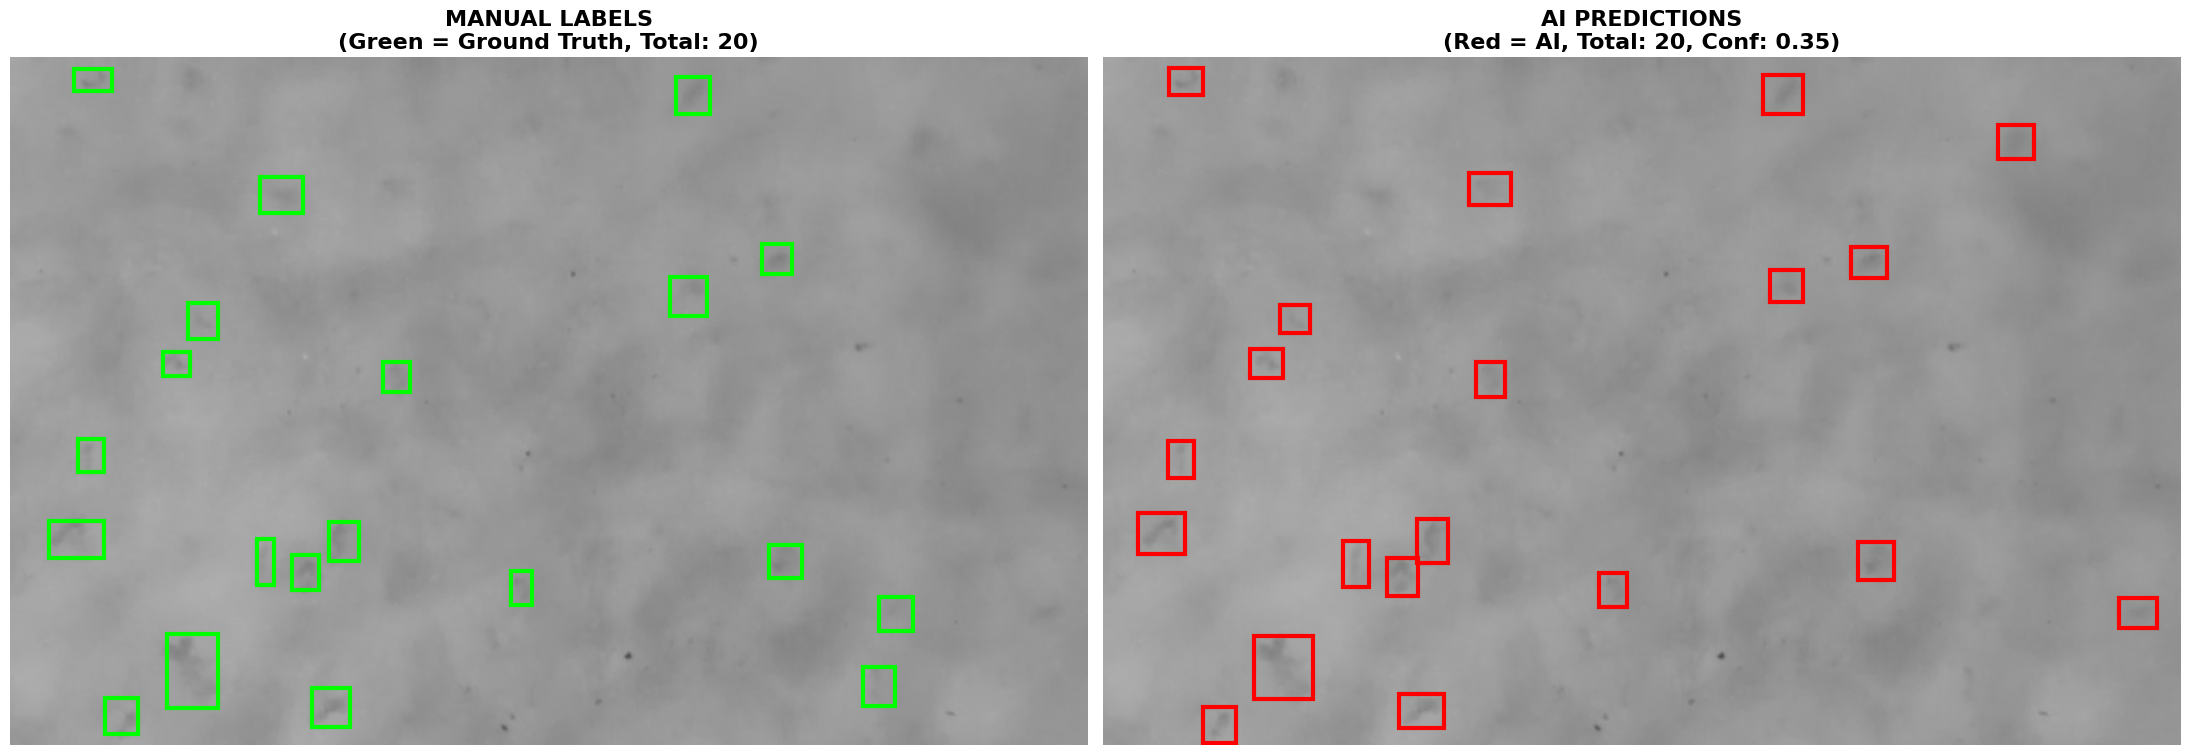

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np
from google.colab import files

# --- THE OPTIMISED THRESHOLD ---
# Strictly locking the confidence threshold to 0.35 to ensure high-precision results
# and eliminate lower-confidence background noise or duplicates.
target_conf = 0.35
fixed_iou = 0.50

# --- IDENTIFY THE OPTIMAL FRAME (Ranked Search) ---
# Iteratively scans the entire test partition to identify the most accurate frame.
#Detections are ranked primarily by agreement with the ground-truth count and secondarily by average confidence.
candidates = []
total_images = len(df_test)

print(f"Scanning {total_images} images for the best frame at exactly {target_conf} confidence...")

for i in range(total_images):
    img_name = df_test.iloc[i]['img']
    img_path = final_split / 'test' / 'images' / img_name
    label_path = final_split / 'test' / 'labels' / (img_name.rsplit('.', 1)[0] + ".txt")

    manual_count = 0
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            manual_count = len(f.readlines())

    # Runs model inference at the selected 0.35 operating threshold
    res = best_model.predict(img_path, conf=target_conf, iou=fixed_iou, verbose=False)[0]
    ai_count = len(res.boxes)

    # Calculates mean confidence to ensure the selected frame contains high-certainty detections
    avg_conf = res.boxes.conf.mean().item() if len(res.boxes) > 0 else 0
    diff = abs(manual_count - ai_count)

    # Filtering logic: Only considers frames with a significant capillary density (5+)
    if manual_count >= 5:
        candidates.append({
            'idx': i,
            'diff': diff,
            'avg_conf': avg_conf,
            'name': img_name,
            'results': res,
            'manual_count': manual_count
        })

# RANKING LOGIC:
# Sorts by lowest count difference first, then by highest average confidence as a tie-breaker.
candidates = sorted(candidates, key=lambda x: (x['diff'], -x['avg_conf']))

# SELECTION INDEX:
# 0 represents the statistically superior match. Increment this value to cycle through alternative top frames.
selected_idx = 0

if not candidates:
    print("No suitable frames found with 5+ capillaries. Please verify dataset paths.")
else:
    # Ensures the selected index remains within the bounds of the candidate list
    selected_idx = min(selected_idx, len(candidates) - 1)

    best_frame_data = candidates[selected_idx]
    best_results = best_frame_data['results']
    img_name = best_frame_data['name']
    manual_total = best_frame_data['manual_count']

    # --- LOAD & PREPARE IMAGE ---
    # Loads the raw frame and converts the colour space from BGR to RGB for accurate anatomical rendering
    img_path = final_split / 'test' / 'images' / img_name
    label_path = final_split / 'test' / 'labels' / (img_name.rsplit('.', 1)[0] + ".txt")

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # ---  PLOT MANUAL VS PREDICTION (Comparison Visualisation) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 11))

    # LEFT: MANUAL
    # Visualises the ground truth annotations provided during the manual labelling process
    ax1.imshow(img)
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) == 5:
                    # Normalises YOLO coordinates back to pixel values for spatial plotting
                    _, x, y, nw, nh = map(float, parts)
                    x1, y1 = int((x - nw/2) * w), int((y - nh/2) * h)
                    x2, y2 = int((x + nw/2) * w), int((y + nh/2) * h)
                    # Green bounding boxes represent the verified manual standard
                    ax1.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='#00FF00', linewidth=3))
    ax1.set_title(f"MANUAL LABELS\n(Green = Ground Truth, Total: {manual_total})", fontsize=16, fontweight='bold')
    ax1.axis('off')

    # RIGHT: PREDICTION (AI Localisation)
    # Visualises the autonomous detection results using the optimised YOLOv8 model weights
    ax2.imshow(img)
    ai_total = len(best_results.boxes)
    for box in best_results.boxes:
        coords = box.xyxy[0].cpu().numpy()
        # Red bounding boxes represent the AI's autonomous capillary localisation
        ax2.add_patch(plt.Rectangle((coords[0], coords[1]), coords[2]-coords[0], coords[3]-coords[1],
                                    fill=False, color='#FF0000', linewidth=3))
    ax2.set_title(f"AI PREDICTIONS\n(Red = AI, Total: {ai_total}, Conf: {target_conf:.2f})", fontsize=16, fontweight='bold')
    ax2.axis('off')

    plt.tight_layout()

    # ---  OUTPUT & EXPORT ---
    print(f"Optimal Frame Selected: {img_name} (Rank: {selected_idx + 1}, Count Difference: {best_frame_data['diff']})")
    save_filename = f"final_best_frame_comparison.png"
    plt.savefig(save_filename, dpi=300) # Exporting at 300 DPI for publication-quality resolution
    plt.show()

    # Automatically triggers the download of the comparison visualisation
    files.download(save_filename)

**Quantitative Error Analysis: False Positive vs. False Negative Distribution**

* **Confusion Matrix Decomposition**: Extracts raw True Positive (TP), False Positive (FP), and False Negative (FN) counts from the validation results.
* **Error Classification**: Distinguishes between "Ghost Detections" (FP) and "Missed Capillaries" (FN) to evaluate the model's reliability in a clinical context.
* **Comparative Visualisation**: Generates a targeted bar chart to provide a clear, high-contrast comparison of error types, aiding in the interpretation of the Precision-Recall trade-off.
* **Data-Driven Diagnostics**: Facilitates a deeper understanding of whether the model is currently biased toward over-detection or under-detection.

True Positives (TP): 1191.0
False Positives (FP): 193.0
False Negatives (FN): 205.0


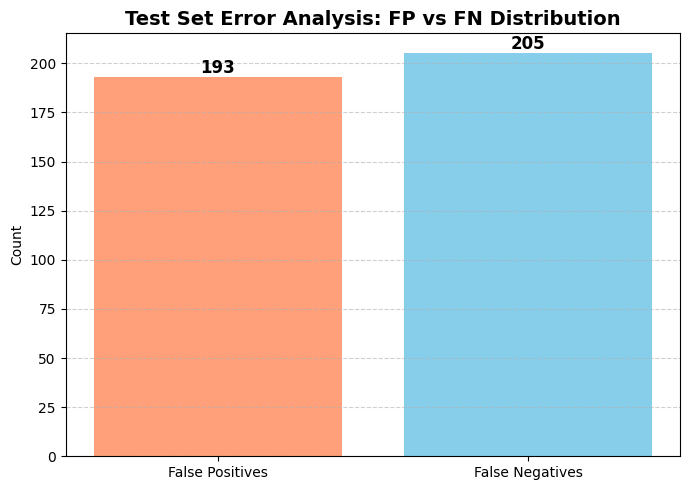

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#EXTRACT DATA FROM CONFUSION MATRIX
# Retrieves the raw numerical matrix comparing labels (Ground Truth) against AI predictions
cm = test_metrics.confusion_matrix.matrix

# For single-class capillary detection:
# Index 0 represents the 'Capillary' class; the final index represents 'Background' (FP/FN)
tp = cm[0, 0] # True Positives: Instances where the AI and human both identified a capillary
fp = cm[0, :].sum() - tp # False Positives: AI identified a capillary where only background exists
fn = cm[:, 0].sum() - tp # False Negatives: AI missed a capillary that was manually annotated

# Print raw counts for verification against performance metrics
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

#VISUAL ERROR ANALYSIS (FP vs FN)
# Prepares categorical labels and data for a focused visualisation of model inaccuracies
labels = ["False Positives", "False Negatives"]
values = [fp, fn]

plt.figure(figsize=(7, 5))
# Creates a bar chart to visually contrast the two primary error modes of the detector
bars = plt.bar(labels, values, color=['#FFA07A', '#87CEEB']) # Distinct colors for FP and FN
plt.ylabel("Count")
plt.title("Test Set Error Analysis: FP vs FN Distribution", fontsize=14, fontweight='bold')

# Analytical Annotations: Places the exact numerical count atop each bar for precise readability
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{int(val)}", ha="center", va="bottom", fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.6) # Improves vertical readability
plt.tight_layout()

#EXPORT RESULTS
# Saves the error analysis chart as a high-resolution file for inclusion in the dissertation
chart_filename = "FP_vs_FN_BarChart.png"
plt.savefig(chart_filename, dpi=300, bbox_inches='tight')
plt.show()

# Triggers a local browser download
files.download(chart_filename)

**Ground Truth Metadata: Test Set Composition**

* **Dataset Verification**: Identifies the specific video held out for the final independent test set, ensuring no overlap with training data.
* **Annotation Quantification**: Parses the YOLO-formatted label files to calculate the total number of manual annotations (Ground Truth).
* **Statistical Baseline**: Establishes the total frame count and average capillary density per frame, providing a reference point for interpreting the model's detection frequency.
* **Integrity Check**: Acts as a final validation step to ensure the data pipeline has correctly partitioned the test files before reporting final results.

In [ ]:

#Defines the path to the folder containing the manual labels for the test set
test_labels_path = final_split / "test" / "labels"

#Identify which video was held out for the test set
test_video_id = df_test['video_id'].unique()[0]

# Count labels and frames total
total_labeled_capillaries = 0
frame_count = 0

#Checks if the label directory exists to prevent script errors
if test_labels_path.exists():
    # Get all .txt files in the test labels folder
    label_files = [f for f in os.listdir(test_labels_path) if f.endswith('.txt')]

    for label_file in label_files:
        with open(test_labels_path / label_file, 'r') as f:
            # Reads the file and counts every line that isn't empty
            #In YOLO format, each line represents one manual bounding box
            lines = f.readlines()
            total_labeled_capillaries += len([line for line in lines if line.strip()])
            frame_count += 1

#Outputs a formal summary of the held-out test set
    print(f"--- HELD-OUT TEST SET SUMMARY ---")
    print(f"Test Video ID:      {test_video_id}")
    print(f"Total Frames:       {frame_count}")
    print(f"Total Capillaries:  {total_labeled_capillaries}") # <--- THIS IS the GROUND TRUTH
    print(f"Avg Caps per Frame: {total_labeled_capillaries/frame_count:.2f}")
else:
    print(f"[!] Error: Path {test_labels_path} not found. Check if 'final_split' is defined correctly.")

--- HELD-OUT TEST SET SUMMARY ---
Test Video ID:      videos_nov_-20250813_140205
Total Frames:       58
Total Capillaries:  1396
Avg Caps per Frame: 24.07


**Confidence Threshold Sensitivity Analysis and Performance Optimisation**

* **Multi-Threshold Comparison**: Aggregates performance data across various confidence intervals (0.25, 0.30, 0.35) to identify the optimal balance for clinical application.
* **Error Distribution Mapping**: Contrasts True Positives, False Positives (Noise), and False Negatives (Misses) against the labelled Ground Truth.
* **Bias Quantification**: Calculates the "Net Difference" and "FP-FN Gap" to determine if the model exhibits a systematic bias toward over-counting or under-counting capillaries.
* **Performance Synthesis**: Utilises a structured comparative report to justify the final selection of the 0.35 threshold as the most balanced configuration for capillary detection in the preeclampsia project.

In [ ]:
# AGGREGATE PERFORMANCE DATA
# Consolidates the results from the threshold sweep for comparative analysis
# Format: [Metric Name, Result @ 0.25, Result @ 0.30, Result @ 0.35]
tp = ["True Positives (Correct)", 1268, 1238, 1191]
fp = ["False Positives (Noise)", 325, 252, 193]
fn = ["False Negatives (Misses)", 128, 158, 205]
precision = ["Precision", 0.7960, 0.8309, 0.8605]
recall = ["Recall", 0.9083, 0.8868, 0.8532]
f1 = ["F1-Score", 0.8484, 0.8579, 0.8568]
gt_labels = ["Total Manual Labels", 1396, 1396, 1396] # The human-verified baseline
ai_counts = ["Total AI Detections", 1593, 1490, 1384] # The raw quantity of boxes drawn by the model

# CALCULATE CLINICAL DERIVED METRICS
# These metrics assess the model's reliability for clinical "capillary density" measurements
net_diff_row = ["Net Difference (Pred - GT)"] # Quantifies overcounting/undercounting error
gap_row = ["FP-FN Gap (Balance)"] # Measures the "skew" between false detections and missed ones

for i in range(1, 4):
    # Calculate Net Difference: Shows the percentage deviation from the manual count
    diff = ai_counts[i] - gt_labels[i]
    perc = (diff / gt_labels[i]) * 100
    net_diff_row.append(f"{diff} ({perc:+.2f}%)")

    # Calculate FP-FN Gap: Lower values indicate a more balanced model where errors "cancel out"
    gap_row.append(abs(fp[i] - fn[i]))

#  ASSEMBLE COMPARATIVE MATRIX
# Structures the raw and derived data into a single grid for professional reporting
comparison_table = [
    [tp[0], f"{tp[1]} (90.83%)", f"{tp[2]} (88.68%)", f"{tp[3]} (85.32%)"],
    [fp[0], f"{fp[1]} (23.28%)", f"{fp[2]} (18.05%)", f"{fp[3]} (13.83%)"],
    [fn[0], f"{fn[1]} (9.17%)", f"{fn[2]} (11.32%)", f"{fn[3]} (14.68%)"],
    precision,
    recall,
    f1,
    gt_labels,
    ai_counts,
    net_diff_row,
    gap_row
]

#  GENERATE PERFORMANCE REPORT
# Outputs the analysis in a high-contrast format suitable for dissertation documentation
headers = ["Metric", "Threshold 0.25", "Threshold 0.30", "Threshold 0.35"]

print("\n" + "═"*85)
print("             COMPARATIVE ANALYSIS: CONFIDENCE THRESHOLD SWEEP             ")
print("═"*85)
# Renders the final comparison using a clean, readable grid layout
print(tabulate(comparison_table, headers=headers, tablefmt="fancy_grid", stralign="center"))
print("═"*85)


═════════════════════════════════════════════════════════════════════════════════════
             COMPARATIVE ANALYSIS: CONFIDENCE THRESHOLD SWEEP             
═════════════════════════════════════════════════════════════════════════════════════
╒════════════════════════════╤══════════════════╤══════════════════╤══════════════════╕
│           Metric           │  Threshold 0.25  │  Threshold 0.30  │  Threshold 0.35  │
╞════════════════════════════╪══════════════════╪══════════════════╪══════════════════╡
│  True Positives (Correct)  │  1268 (90.83%)   │  1238 (88.68%)   │  1191 (85.32%)   │
├────────────────────────────┼──────────────────┼──────────────────┼──────────────────┤
│  False Positives (Noise)   │   325 (23.28%)   │   252 (18.05%)   │   193 (13.83%)   │
├────────────────────────────┼──────────────────┼──────────────────┼──────────────────┤
│  False Negatives (Misses)  │   128 (9.17%)    │   158 (11.32%)   │   205 (14.68%)   │
├────────────────────────────┼──────────────────

# Stratified Group Cross-Validation Pipeline and Statistical Evaluation

**Stratified Nested Cross-Validation: Architectural Setup and Data Partitioning**

* **Leakage Prevention Protocol**: Implements a Group-based split using Video IDs to ensure that frames from the same clinical video never appear in both the training and evaluation sets simultaneously.
* **Stratified Density Balancing**: Categorises frames into "difficulty bins" based on capillary density, ensuring each fold represents the full anatomical variety of the dataset.
* **Nested Architecture**:
    * **Outer Loop (5 Folds)**: Reserves independent test sets to provide an unbiased estimate of real-world generalisation.
    * **Inner Loop (3 Folds)**: Facilitates rigorous hyperparameter tuning and model selection without "peeking" at the final evaluation data.


In [ ]:
# =========================
# SETTINGS
# =========================
output_cv_folder = project_folder / "nested_cv" #Defines the main directory where all the CV folds will be organised
raw_data_source = cleaned_area #The source folder containing the cleaned images and label files
outer_folds = 5 #Number of outer loops used to estimate how well the model generalises to new data
inner_folds = 3 #Number of inner loops used to tune hyperparameters to select the best model settings
density_bins = 5 #Number of bins to categorise image difficulty based on how many capillaries are present
random_seed = 42 #Ensuring the random splits are reproducible every time the script runs

# =========================
# HELPERS
# =========================
#Function to count the number of annotated capillaries in a single YOLO .txt file
def get_capillary_count(label_path):
    if not label_path.exists():
        return 0
    with open(label_path, "r") as file:
        #Sums up the number of non-empty lines
        return sum(1 for line in file if line.strip())

#Function to move images and labels into specific fold directories
def copy_rows_to_split(source_df, row_indices, split_root, raw_data_source):
    image_out = split_root / "images"
    label_out = split_root / "labels"
    image_out.mkdir(parents=True, exist_ok=True)
    label_out.mkdir(parents=True, exist_ok=True)

    #Iterates through the list of row numbers chosen for this specific split
    for idx in row_indices:
        row = source_df.iloc[idx]

        #Copy the image file to the destination folder
        shutil.copy2(row["image_path"], image_out / row["image_path"].name)

        #Determine the label name by swapping .jpg for .txt
        label_source = raw_data_source / f"{row['image_path'].stem}.txt"
        #Copy the label file if it exists, or create a blank file
        if label_source.exists():
            shutil.copy2(label_source, label_out / label_source.name)
        else:
            (label_out / f"{row['image_path'].stem}.txt").touch()

#Function to write the data.yaml file that tells YOLO where to find the images
def write_data_yaml(folder_path, train_rel, val_rel, yaml_name="data.yaml"):
    yaml_content = {
        "path": str(folder_path.absolute()), #Absolute path to the fold directory
        "train": train_rel, #Relative path to training images
        "val": val_rel, #Relative path to validation images
        "nc": 1, #Number of classes
        "names": ["capillary"] #The class name
    }
    with open(folder_path / yaml_name, "w") as f:
        yaml.dump(yaml_content, f)

#Logic to determine if the code can split by both video group and difficulty rank
def get_splitter(df, n_splits, seed):
    unique_groups = df["video_group"].nunique()
    # Safety check to ensure the number of splits does not exceed the number of unique videos
    if unique_groups < n_splits:
        raise ValueError(
            f"Need at least {n_splits} unique video groups, but found only {unique_groups}."
        )
    #If density bins exist, use StratifiedGroupKFold to keep video groups together AND balanced
    if "difficulty_rank" in df.columns and df["difficulty_rank"].nunique() > 1:
        splitter = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )
        split_list = list(
            splitter.split(
                df,
                y=df["difficulty_rank"],
                groups=df["video_group"]
            )
        )
        split_name = "StratifiedGroupKFold"
    else:
        #Fallback to standard GroupKFold if stratification is not possible
        splitter = GroupKFold(n_splits=n_splits)
        split_list = list(
            splitter.split(
                df,
                groups=df["video_group"]
            )
        )
        split_name = "GroupKFold"

    return split_list, split_name

# =========================
# BUILD DATASET MANIFEST
# =========================
#Scan the directory for all the JPG images
image_files = sorted(list(raw_data_source.glob("*.[jJ][pP][gG]")))
manifest_entries = []

#Load the metadata to link images to their parent videos
video_registry = pd.read_csv(project_folder / "metadata.csv")

#Create a list of metadata for every image found on disk
for img_path in image_files:
    current_filename = img_path.name

    #Look where the image came from
    video_match = video_registry[video_registry["img"] == current_filename]
    if not video_match.empty:
        parent_video_id = video_match["video_id"].iloc[0]
    else:
        parent_video_id = "unknown_video"
    #Get the number of capillaries in this specific frame
    cap_count = get_capillary_count(raw_data_source / f"{img_path.stem}.txt")

    manifest_entries.append({
        "image_path": img_path,
        "video_group": parent_video_id,
        "capillary_density": cap_count
    })
#Turns the list of metadata into a master DataFrame
dataset_df = pd.DataFrame(manifest_entries)

if dataset_df.empty:
    raise ValueError(f"No images found in {raw_data_source}. Check your cleaning step.")

#Clean out any previous CV folders to prevent mixing from old runs
if output_cv_folder.exists():
    shutil.rmtree(output_cv_folder)
output_cv_folder.mkdir(parents=True, exist_ok=True)

# Saves the master manifest so the splits can be verified manually if needed
dataset_df.to_csv(output_cv_folder / "full_manifest.csv", index=False)

# =========================
# CREATE STRATIFICATION BINS
# =========================

#Use quantile cutting to divide the images into 5 difficulty levels based on capillary count
if dataset_df["capillary_density"].nunique() < 2:
    dataset_df["difficulty_rank"] = 0
else:
    dataset_df["difficulty_rank"] = pd.qcut(
        dataset_df["capillary_density"],
        q=density_bins,
        labels=False,
        duplicates="drop"
    )

    #If qcut collapses too much, fall back to non-stratified grouping
    if pd.Series(dataset_df["difficulty_rank"]).nunique() < 2:
        dataset_df["difficulty_rank"] = 0

print("Unique videos:", dataset_df["video_group"].nunique())
print("Unique density bins:", pd.Series(dataset_df["difficulty_rank"]).nunique())

# =========================
# OUTER SPLITS
# =========================

#Create the 5 main partitions of the data
outer_splits, outer_splitter_name = get_splitter(dataset_df, outer_folds, random_seed)
print(f"Outer splitter used: {outer_splitter_name}")

for outer_idx, (outer_train_idx, outer_test_idx) in enumerate(outer_splits, start=1):
    #Create the folder for the current outer fold
    print(f"Creating outer fold {outer_idx}/{outer_folds}")

    outer_fold_path = output_cv_folder / f"outer_fold_{outer_idx}"
    outer_fold_path.mkdir(parents=True, exist_ok=True)

    #Subdivide the main manifest into training and testing portions for this fold
    outer_train_df = dataset_df.iloc[outer_train_idx].reset_index(drop=True)
    outer_test_df = dataset_df.iloc[outer_test_idx].reset_index(drop=True)

    #Save outer test set which will only be used for final evaluation
    copy_rows_to_split(
        source_df=dataset_df,
        row_indices=outer_test_idx,
        split_root=outer_fold_path / "test",
        raw_data_source=raw_data_source
    )

    # -------------------------
    # INNER SPLITS FROM OUTER TRAIN ONLY
    # -------------------------

    #Split the outer training data again into 3 folds for hyperparameter tuning
    inner_splits, inner_splitter_name = get_splitter(
        outer_train_df,
        inner_folds,
        random_seed + outer_idx
    )
    print(f" Inner splitter used: {inner_splitter_name}")

    for inner_idx, (inner_train_idx, inner_val_idx) in enumerate(inner_splits, start=1):
        inner_fold_path = outer_fold_path / f"inner_fold_{inner_idx}"
        inner_fold_path.mkdir(parents=True, exist_ok=True)

        #Copy data for the inner training and validation loops
        copy_rows_to_split(
            source_df=outer_train_df,
            row_indices=inner_train_idx,
            split_root=inner_fold_path / "train",
            raw_data_source=raw_data_source
        )
        copy_rows_to_split(
            source_df=outer_train_df,
            row_indices=inner_val_idx,
            split_root=inner_fold_path / "val",
            raw_data_source=raw_data_source
        )
        #Write the YAML for this specific inner experiment
        write_data_yaml(
            folder_path=inner_fold_path,
            train_rel="train/images",
            val_rel="val/images",
            yaml_name="data.yaml"
        )

    # -------------------------
    # FINAL REFIT SPLIT INSIDE OUTER TRAIN
    # this is used for the final outer-fold training
    # -------------------------
    #Once tuning is done, prepare to train on the full outer training set
    refit_splits, _ = get_splitter(
        outer_train_df,
        inner_folds,
        random_seed + 1000 + outer_idx
    )
    refit_train_idx, refit_val_idx = refit_splits[0]
    #Create a refit folder to train the final model for this outer fold
    copy_rows_to_split(
        source_df=outer_train_df,
        row_indices=refit_train_idx,
        split_root=outer_fold_path / "refit_train",
        raw_data_source=raw_data_source
    )
    copy_rows_to_split(
        source_df=outer_train_df,
        row_indices=refit_val_idx,
        split_root=outer_fold_path / "refit_val",
        raw_data_source=raw_data_source
    )

    #Yaml for final training inside this outer fold
    write_data_yaml(
        folder_path=outer_fold_path,
        train_rel="refit_train/images",
        val_rel="refit_val/images",
        yaml_name="refit_data.yaml"
    )

    #Yaml for final outer test evaluation
    write_data_yaml(
        folder_path=outer_fold_path,
        train_rel="refit_train/images",
        val_rel="test/images",
        yaml_name="test_eval.yaml"
    )

print(f"\nSuccessfully created nested CV folders in: {output_cv_folder}")

Unique videos: 11
Unique density bins: 5
Outer splitter used: StratifiedGroupKFold
Creating outer fold 1/5
 Inner splitter used: StratifiedGroupKFold
Creating outer fold 2/5
 Inner splitter used: StratifiedGroupKFold
Creating outer fold 3/5
 Inner splitter used: StratifiedGroupKFold
Creating outer fold 4/5
 Inner splitter used: StratifiedGroupKFold
Creating outer fold 5/5
 Inner splitter used: StratifiedGroupKFold

Successfully created nested CV folders in: /content/drive/MyDrive/capillary_CV_project/nested_cv


**Nested Cross-Validation Training Pipeline**

* Sets up global training parameters like the base YOLOv8 model.

* Initiates a loop that runs for outer_folds times where each iteration represents a complete nested cross-validation cycle, with its own testing, training and validation phases.

* In each outer fold an inner loop tests different hyperparameter combinations.

* After evaluating all candidate configurations in the inner loop, the model identifies the best-performing set of hyperparameters based on the mean mAP@50 across inner folds.

* Using the selected best hyperparameters, a fresh YOLO model is trained on the full outer training set.

* The trained model from the final outer fold training is then evaluated against its held out test set to provide an unbiased performance estimate.

In [ ]:

# =========================
# TRAINING SETTINGS
# =========================
#Loads the nano version of YOLOv8 as the starting point for training
base_model = "yolov8n.pt"
#Sets the directory where all training logs, weights, and results will be saved
runs_dir = project_folder / "runs_nested"
runs_dir.mkdir(parents=True, exist_ok=True)

#Training limits inner is shorter for quick testing, outer is longer for final learning
INNER_EPOCHS = 60
OUTER_EPOCHS = 150

#How many epochs to wait for improvement before stopping early to save time
INNER_PATIENCE = 15
OUTER_PATIENCE = 30
# The resolution images are resized for small objects like capillaries
IMG_SIZE = 1280
CLOSE_MOSAIC = 20 #Disables data augmentation for the last 20 epochs to stabilise training

#Tune a few candidate settings in the inner loop based on full dataset training parameters and two other sets of hyperparameters
candidate_configs = [
    {
        "lr0": 5e-4,
        "batch": 8,
        "optimizer": "AdamW",
        "box": 7.5,
        "cls": 0.5,
        "dfl": 1.5,
        "lrf": 0.1,
        "weight_decay": 1e-2,
        "warmup_epochs": 5,
        "mosaic": 0.5,
        "mixup": 0.0
    },
    {
        "lr0": 1e-3,
        "batch": 8,
        "optimizer": "AdamW",
        "box": 7.5,
        "cls": 0.5,
        "dfl": 1.5,
        "lrf": 0.1,
        "weight_decay": 1e-2,
        "warmup_epochs": 5,
        "mosaic": 0.5,
        "mixup": 0.0
    },
    {
        "lr0": 5e-4,
        "batch": 8,
        "optimizer": "SGD",
        "box": 7.5,
        "cls": 0.5,
        "dfl": 1.5,
        "lrf": 0.1,
        "weight_decay": 1e-2,
        "warmup_epochs": 5,
        "mosaic": 0.5,
        "mixup": 0.0
    }
]
#Function to pull specific performance numbers (mAP, F1) out of the YOLO results object
def extract_val_metrics(metrics_obj):
    precision = float(metrics_obj.box.mp)
    recall = float(metrics_obj.box.mr)
    map50 = float(metrics_obj.box.map50)
    map50_95 = float(metrics_obj.box.map)

#Calculates F1 score the balance between Precision and Recall
    f1 = 2 * (precision * recall) / (precision + recall + 1e-9)


    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "map50": map50,
        "map50_95": map50_95,

    }
#Lists to store the report card for every training run
inner_cv_records = []
outer_cv_records = []

#Start the outer loop
for outer_fold in range(1, outer_folds + 1):
    print(f"\n========== OUTER FOLD {outer_fold}/{outer_folds} ==========")

    outer_fold_path = output_cv_folder / f"outer_fold_{outer_fold}"

    best_candidate = None
    best_candidate_score = -np.inf

    # -------------------------
    # INNER LOOP: choose best hyperparameters
    # -------------------------
    #Test each set of hyperparameters in the candidate_configs list
    for cand_idx, cand in enumerate(candidate_configs, start=1):
        print(f"\nTesting candidate {cand_idx}: {cand}")

        candidate_inner_scores = []
#Run Cross-validation for this specific recipe
        for inner_fold in range(1, inner_folds + 1):
            print(f"  Training inner fold {inner_fold}/{inner_folds}")

            inner_yaml = outer_fold_path / f"inner_fold_{inner_fold}" / "data.yaml"
            run_name = f"outer_{outer_fold}_inner_{inner_fold}_cand_{cand_idx}"
#Initialise and train the model with the current candidate settings
            model = YOLO(base_model)
            model.train(
                data=str(inner_yaml),
                epochs=INNER_EPOCHS,
                imgsz=IMG_SIZE,
                batch=cand["batch"],
                patience=INNER_PATIENCE,
                lr0=cand["lr0"],
                lrf=cand["lrf"],
                weight_decay=cand["weight_decay"],
                warmup_epochs=cand["warmup_epochs"],
                box=cand["box"],
                cls=cand["cls"],
                dfl=cand["dfl"],
                mosaic=cand["mosaic"],
                mixup=cand["mixup"],
                optimizer=cand["optimizer"],
                close_mosaic=CLOSE_MOSAIC,
                project=str(runs_dir),
                name=run_name,
                exist_ok=True
            )
            #Load the best weights from that training session to validate it

            best_weights = runs_dir / run_name / "weights" / "best.pt"
            best_model = YOLO(str(best_weights))
#Run validation to see how the model performed
            val_metrics = best_model.val(
                data=str(inner_yaml),
                split="val",
                plots=False,
                save=False
            )
#Record the metrics and the settings used
            metric_row = extract_val_metrics(val_metrics)
            metric_row.update({
                "outer_fold": outer_fold,
                "inner_fold": inner_fold,
                "candidate_id": cand_idx,
                **cand
            })

            inner_cv_records.append(metric_row)
            candidate_inner_scores.append(metric_row["map50"])

            print(f"    inner fold mAP50 = {metric_row['map50']:.4f}")
#Calculate the average performance for this recipe across all inner folds
        mean_candidate_map50 = float(np.mean(candidate_inner_scores))
        print(f"  Mean inner mAP50 for candidate {cand_idx}: {mean_candidate_map50:.4f}")
#If this hyperparameter set is the best so far, save it as the winner for this outer fold
        if mean_candidate_map50 > best_candidate_score:
            best_candidate_score = mean_candidate_map50
            best_candidate = cand.copy()
            best_candidate["candidate_id"] = cand_idx

    print(f"\nBest candidate for outer fold {outer_fold}: {best_candidate}")

    #Save chosen config
    with open(outer_fold_path / "best_candidate.json", "w") as f:
        json.dump(best_candidate, f, indent=2)

    # -------------------------
    # FINAL TRAINING FOR THIS OUTER FOLD
    # -------------------------

    #Now train a fresh model using the winning parameters on the larger training set
    final_yaml = outer_fold_path / "refit_data.yaml"
    final_run_name = f"outer_{outer_fold}_final"

    model = YOLO(base_model)
    model.train(
        data=str(final_yaml),
        epochs=OUTER_EPOCHS,
        imgsz=IMG_SIZE,
        batch=best_candidate["batch"],
        patience=OUTER_PATIENCE,
        lr0=best_candidate["lr0"],
        lrf=best_candidate["lrf"],
        weight_decay=best_candidate["weight_decay"],
        warmup_epochs=best_candidate["warmup_epochs"],
        box=best_candidate["box"],
        cls=best_candidate["cls"],
        dfl=best_candidate["dfl"],
        mosaic=best_candidate["mosaic"],
        mixup=best_candidate["mixup"],
        optimizer=best_candidate["optimizer"],
        close_mosaic=CLOSE_MOSAIC,
        project=str(runs_dir),
        name=final_run_name,
        exist_ok=True
    )

    # -------------------------
    # OUTER TEST EVALUATION
    # -------------------------
    #Test the final model against the holdout set
    best_weights = runs_dir / final_run_name / "weights" / "best.pt"
    best_model = YOLO(str(best_weights))

    test_yaml = outer_fold_path / "test_eval.yaml"
    test_metrics = best_model.val(
        data=str(test_yaml),
        split="val",
        plots=False,
        save=False
    )
#Log these final results, they are the true performance metrics for the project
    outer_row = extract_val_metrics(test_metrics)
    outer_row.update({
        "outer_fold": outer_fold,
        "chosen_candidate_id": best_candidate["candidate_id"],
        "lr0": best_candidate["lr0"],
        "batch": best_candidate["batch"],
        "optimizer": best_candidate["optimizer"],
        "box": best_candidate["box"],
        "cls": best_candidate["cls"],
        "dfl": best_candidate["dfl"],
        "lrf": best_candidate["lrf"],
        "weight_decay": best_candidate["weight_decay"],
        "warmup_epochs": best_candidate["warmup_epochs"],
        "mosaic": best_candidate["mosaic"],
        "mixup": best_candidate["mixup"]
    })

    outer_cv_records.append(outer_row)

    print(
        f"OUTER TEST RESULTS | "
        f"P={outer_row['precision']:.4f}, "
        f"R={outer_row['recall']:.4f}, "
        f"F1={outer_row['f1']:.4f}, "
        f"mAP50={outer_row['map50']:.4f}, "
        f"mAP50:95={outer_row['map50_95']:.4f}"
    )

#Save results into CSV files for analysis
inner_results_df = pd.DataFrame(inner_cv_records)
outer_results_df = pd.DataFrame(outer_cv_records)

inner_results_df.to_csv(project_folder / "nested_inner_cv_results.csv", index=False)
outer_results_df.to_csv(project_folder / "nested_outer_cv_results.csv", index=False)

print("\nSaved:")
print(project_folder / "nested_inner_cv_results.csv")
print(project_folder / "nested_outer_cv_results.csv")

Streaming output truncated to the last 5000 lines.
                   all        156       4179      0.704      0.634      0.672      0.256

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       9/60       6.5G      2.013      1.264      1.284        158       1280: 100% ━━━━━━━━━━━━ 43/43 3.3it/s 13.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.2it/s 1.9s
                   all        156       4179      0.694      0.662      0.675      0.238

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      10/60       6.5G      1.994      1.291      1.288        242       1280: 100% ━━━━━━━━━━━━ 43/43 3.4it/s 12.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.4it/s 1.9s
                   all        156       4179      0.712      0.601      0.669      0.261

      Epoch    GPU_mem   box_loss  

**Nested Cross-Validation: Statistical Evaluation and Visualisation**

* Loads the CV results which contain performance metrics from the nested cross-validation runs.

* Calculates Mean ± Std for the key metrics such as Precision, Recall, F1 and mAP@50.

* Generates a summary table summarising these mean and standard deviation values.

* Creates a bar chart visualising the mean performance metrics for training vs. testing, with error bars indicating standard deviation.

* Plots metric convergence plots to show the mean ± std across all folds, indicating convergence and consistency.

* Plots loss convergence for the mean training and validation total loss over epochs.


=== TRAIN / TEST SUMMARY TABLE ===
    Metric  Training Mean  Training Std Training Mean ± Std  Testing Mean  Testing Std Testing Mean ± Std
Precision         0.7561        0.0327     0.7561 ± 0.0327        0.7581       0.0136    0.7581 ± 0.0136
   Recall         0.7454        0.0689     0.7454 ± 0.0689        0.7294       0.0630    0.7294 ± 0.0630
       F1         0.7497        0.0502     0.7497 ± 0.0502        0.7422       0.0326    0.7422 ± 0.0326
    mAP50         0.7809        0.0698     0.7809 ± 0.0698        0.7654       0.0547    0.7654 ± 0.0547
 mAP50:95         0.3033        0.0320     0.3033 ± 0.0320        0.2940       0.0240    0.2940 ± 0.0240


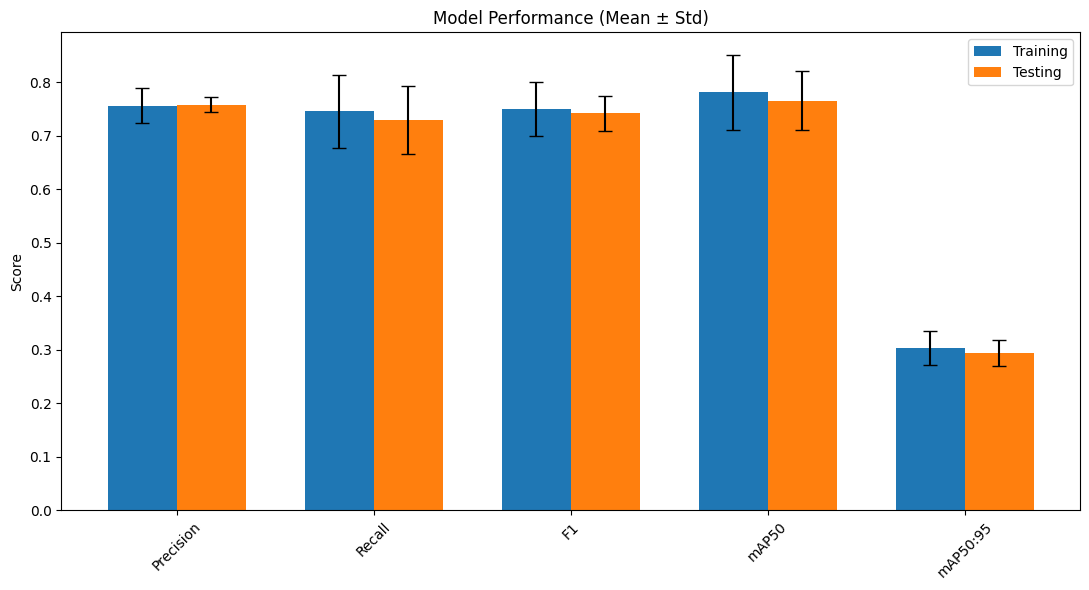

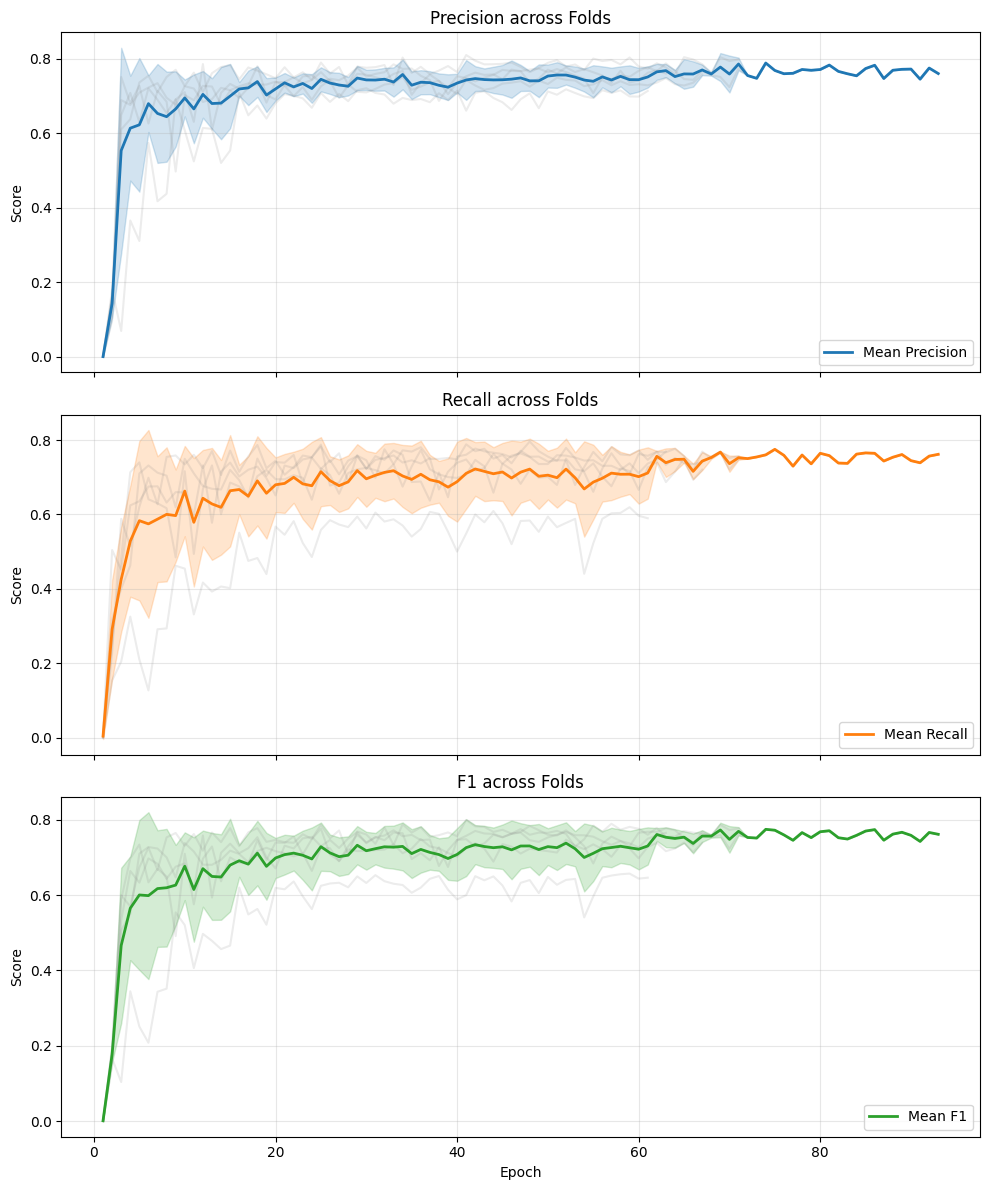

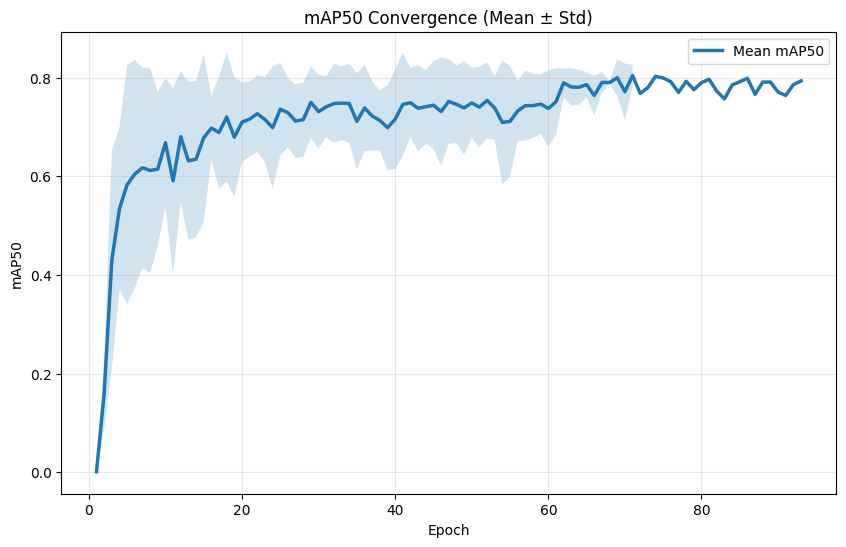

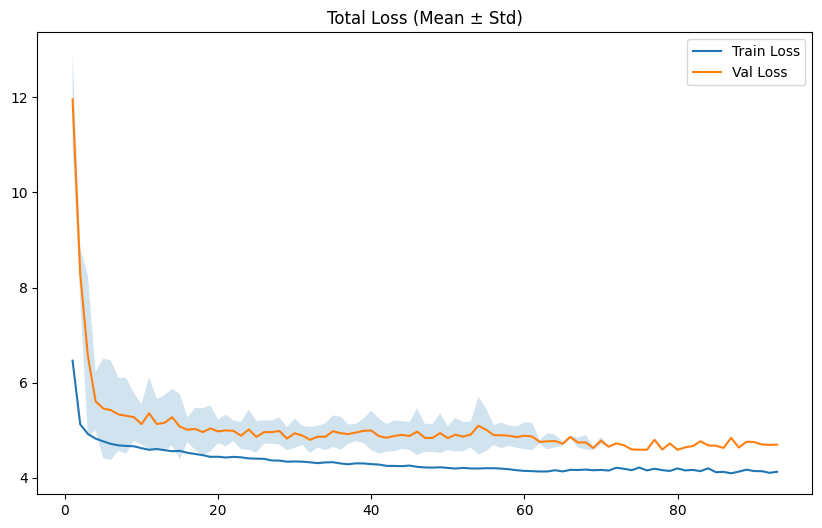


All plots and CSVs saved to: /content/drive/MyDrive/capillary_CV_project


In [ ]:
# =========================================================
# PATHS & CONFIG
# =========================================================
# Setting up the directory structure to locate where the CV results and YOLO runs are stored
results_dir = Path(project_folder)
runs_dir = results_dir / "runs_nested"

# Points to the CSV files created during the training phase
train_csv = results_dir / "nested_inner_cv_results.csv"
test_csv  = results_dir / "nested_outer_cv_results.csv"

# Defining the names for all the summary tables and graphs this script will generate
summary_table_csv = results_dir / "train_test_mean_std_summary.csv"
epoch_metric_summary_csv = results_dir / "epochwise_curve_mean_std.csv"

# Paths for various visualisation plots (Bar charts, mAP curves, Loss curves, etc.)
summary_plot_path = results_dir / "metric_summary_barplot.png"
map50_all_folds_plot_path = results_dir / "map50_all_folds_convergence.png"
map50_mean_std_plot_path = results_dir / "map50_mean_std_convergence.png"
loss_mean_std_plot_path = results_dir / "loss_mean_std_convergence.png"
prf1_convergence_plot_path = results_dir / "precision_recall_f1_convergence.png"
all_curves_plot_path = results_dir / "all_training_validation_curves_mean_std.png"

# =========================================================
# 1) LOAD TRAIN / TEST SUMMARY CSVs
# =========================================================
# Reads the CSVs that contain the performance of each of the 5 folds
train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

# Reformatting column names from technical codes to pretty labels for the graphs
rename_map = {
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "map50": "mAP50",
    "map50_95": "mAP50:95",
}

train_df = train_df.rename(columns=rename_map)
test_df = test_df.rename(columns=rename_map)
metrics = ["Precision", "Recall", "F1", "mAP50", "mAP50:95"]

# Create Mean ± Std Table: This calculates the average and consistency across all folds
summary_rows = []
for metric in metrics:
    # Calculating mean and standard deviation (ddof=1 is used for sample standard deviation)
    train_mean, train_std = train_df[metric].mean(), train_df[metric].std(ddof=1)
    test_mean, test_std = test_df[metric].mean(), test_df[metric].std(ddof=1)

    summary_rows.append({
        "Metric": metric,
        "Training Mean": round(train_mean, 4),
        "Training Std": round(train_std, 4),
        "Training Mean ± Std": f"{train_mean:.4f} ± {train_std:.4f}",
        "Testing Mean": round(test_mean, 4),
        "Testing Std": round(test_std, 4),
        "Testing Mean ± Std": f"{test_mean:.4f} ± {test_std:.4f}",
    })

# Saves the final statistical summary to a new CSV
summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(summary_table_csv, index=False)
print("\n=== TRAIN / TEST SUMMARY TABLE ===\n", summary_table.to_string(index=False))

# Bar Plot Generation: Visualises how Training vs Testing performance compares
x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(11, 6))
# Plots training bars with error bars representing standard deviation
plt.bar(x - width/2, [train_df[m].mean() for m in metrics], width, yerr=[train_df[m].std() for m in metrics], capsize=5, label="Training")
# Plots testing bars side-by-side
plt.bar(x + width/2, [test_df[m].mean() for m in metrics], width, yerr=[test_df[m].std() for m in metrics], capsize=5, label="Testing")
plt.xticks(x, metrics, rotation=45)
plt.ylabel("Score")
plt.title("Model Performance (Mean ± Std)")
plt.legend()
plt.tight_layout()
plt.savefig(summary_plot_path, dpi=300)
plt.show()

# =========================================================
# 2) READ YOLO results.csv & CALCULATE F1
# =========================================================
# Mapping dictionaries to find the correct column names in YOLO's results.csv
COLUMN_CANDIDATES = {
    "epoch": ["epoch"],
    "map50": ["metrics/mAP50(B)"],
    "precision": ["metrics/precision(B)"],
    "recall": ["metrics/recall(B)"],
    "train_box": ["train/box_loss"], "train_cls": ["train/cls_loss"], "train_dfl": ["train/dfl_loss"],
    "val_box": ["val/box_loss"], "val_cls": ["val/cls_loss"], "val_dfl": ["val/dfl_loss"]
}

# Helper function to find which column name YOLO used
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    return None

fold_curves = []
# Loop through each outer fold to extract the learning curves (Loss/mAP per epoch)
for fold in range(1, outer_folds + 1):
    path = runs_dir / f"outer_{fold}_final" / "results.csv"
    if not path.exists(): continue

    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns] # Clean white space from headers

    # Link the specific YOLO column names to the analysis variables
    p_col = find_col(df, COLUMN_CANDIDATES["precision"])
    r_col = find_col(df, COLUMN_CANDIDATES["recall"])
    m_col = find_col(df, COLUMN_CANDIDATES["map50"])
    e_col = find_col(df, COLUMN_CANDIDATES["epoch"])

    temp_df = pd.DataFrame({
        "outer_fold": fold,
        "epoch": df[e_col],
        "mAP50": df[m_col],
        "Precision": df[p_col],
        "Recall": df[r_col]
    })

    # Manual F1-score calculation
    temp_df["F1"] = 2 * (temp_df["Precision"] * temp_df["Recall"]) / (temp_df["Precision"] + temp_df["Recall"] + 1e-8)

    # Aggregating different loss types (Box, Classification, and Distribution Focal Loss)
    for l_type in ["train_box", "train_cls", "train_dfl", "val_box", "val_cls", "val_dfl"]:
        col = find_col(df, COLUMN_CANDIDATES[l_type])
        if col: temp_df[l_type] = df[col]

    # Calculate the Total Loss (the sum of the three individual loss components)
    if "train_box" in temp_df.columns:
        temp_df["train_total_loss"] = temp_df[["train_box", "train_cls", "train_dfl"]].sum(axis=1)
        temp_df["val_total_loss"] = temp_df[["val_box", "val_cls", "val_dfl"]].sum(axis=1)

    fold_curves.append(temp_df)

# Combines data from all 5 folds into one giant table
all_curves_df = pd.concat(fold_curves, ignore_index=True)

# Grouping by epoch to find the average performance across all 5 folds at each point in time
numeric_cols = [c for c in all_curves_df.columns if c not in ["outer_fold", "epoch"]]
epoch_summary = all_curves_df.groupby("epoch")[numeric_cols].agg(["mean", "std"])
epoch_summary.columns = [f"{m}_{s}" for m, s in epoch_summary.columns]
epoch_summary = epoch_summary.reset_index()

# =========================================================
# 3) PLOTTING PRECISION, RECALL, F1 CONVERGENCE
# =========================================================
# Creating a 3-row subplot for P, R, and F1 curves
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
prf_metrics = ["Precision", "Recall", "F1"]
epochs = epoch_summary["epoch"]

for i, metric in enumerate(prf_metrics):
    ax = axes[i]
    # Draws thin grey lines for each individual fold's path
    for fold_id, fold_df in all_curves_df.groupby("outer_fold"):
        ax.plot(fold_df["epoch"], fold_df[metric], alpha=0.15, color='gray')

    # Draws a bold line for the mean and a shaded "ribbon" for the variance (Standard Deviation)
    mean_val = epoch_summary[f"{metric}_mean"]
    std_val = epoch_summary[f"{metric}_std"].fillna(0)
    ax.plot(epochs, mean_val, linewidth=2, label=f"Mean {metric}", color=f'C{i}')
    ax.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2, color=f'C{i}')

    ax.set_ylabel("Score")
    ax.set_title(f"{metric} across Folds")
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Epoch")
plt.tight_layout()
plt.savefig(prf1_convergence_plot_path, dpi=300)
plt.show()

# =========================================================
# 4) PLOT mAP50 & LOSS (Main Training Graphs)
# =========================================================
# Generating the mAP50 Convergence graph - the primary indicator of detection performance
plt.figure(figsize=(10, 6))
plt.plot(epochs, epoch_summary["mAP50_mean"], linewidth=2.5, label="Mean mAP50")
plt.fill_between(epochs, epoch_summary["mAP50_mean"] - epoch_summary["mAP50_std"],
                 epoch_summary["mAP50_mean"] + epoch_summary["mAP50_std"], alpha=0.2)
plt.title("mAP50 Convergence (Mean ± Std)")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(map50_mean_std_plot_path, dpi=300)
plt.show()

# Generating the Loss graph - shows how the model learned to minimise errors over time
if "train_total_loss_mean" in epoch_summary.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, epoch_summary["train_total_loss_mean"], label="Train Loss")
    plt.plot(epochs, epoch_summary["val_total_loss_mean"], label="Val Loss")
    # Shaded area highlights the consistency of the validation loss across folds
    plt.fill_between(epochs, epoch_summary["val_total_loss_mean"] - epoch_summary["val_total_loss_std"],
                     epoch_summary["val_total_loss_mean"] + epoch_summary["val_total_loss_std"], alpha=0.2)
    plt.title("Total Loss (Mean ± Std)")
    plt.legend()
    plt.savefig(loss_mean_std_plot_path, dpi=300)
    plt.show()

print(f"\nAll plots and CSVs saved to: {results_dir}")

**Additional Cross-Validation Visualisation**

* This block generates clearer convergence plots for precision, recall, F1-score and mAP@50 across the five outer folds. These plots support the assessment of fold-to-fold consistency and model stability.

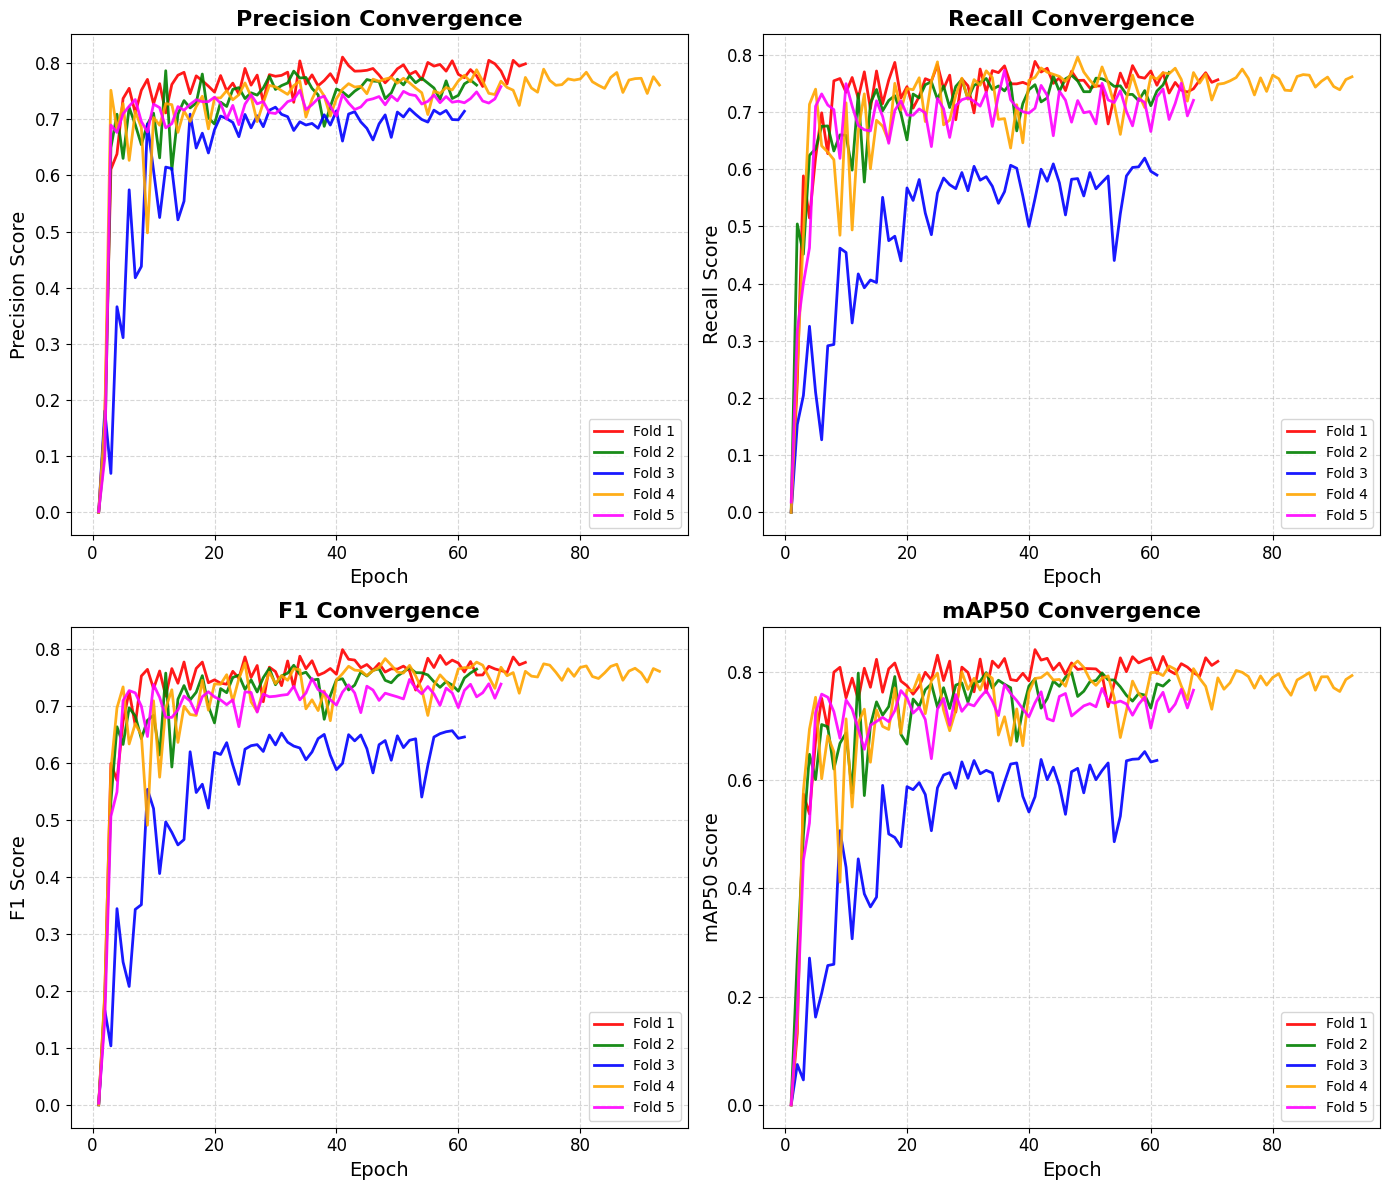

In [ ]:
# =========================================================
#  PLOTTING: PRECISION, RECALL, F1, mAP50 ACROSS FOLDS (2x2)
# =========================================================
# Initialise a figure with a 2x2 grid of subplots and set overall dimensions
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# Define the list of evaluation metrics to be visualised in the subplots
plot_metrics = ["Precision", "Recall", "F1", "mAP50"]

# Convert the 2x2 axes matrix into a 1D array for simpler iterative access
axes_flat = axes.flatten()

# Provide a list of distinct colours to differentiate individual folds
bright_colors = ['red', 'green', 'blue', 'orange', 'magenta', 'cyan', 'yellow']

# Set constant variables for font sizes to maintain consistency across all labels
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

# Iterate through the selected metrics to populate each subplot
for i, metric in enumerate(plot_metrics):
    # Select the current subplot axis corresponding to the metric index
    ax = axes_flat[i]

    # Group the dataframe by fold ID and iterate to plot each fold's curve
    for fold_idx, (fold_id, fold_df) in enumerate(all_curves_df.groupby("outer_fold")):
        # Select a colour from the defined list using the modulo operator to prevent index errors
        color = bright_colors[fold_idx % len(bright_colors)]

        # Plot the metric values against epochs for the specific fold
        ax.plot(
            fold_df["epoch"],
            fold_df[metric],
            alpha=0.9,
            linewidth=2.0,
            color=color,
            label=f"Fold {fold_id}"
        )

    # Set the subplot title with bold formatting and specified font size
    ax.set_title(f"{metric} Convergence", fontsize=TITLE_SIZE, fontweight='bold')
    # Label the x-axis as Epoch with specified font size
    ax.set_xlabel("Epoch", fontsize=LABEL_SIZE)
    # Label the y-axis with the metric name and specified font size
    ax.set_ylabel(f"{metric} Score", fontsize=LABEL_SIZE)

    # Configure the numerical tick labels on both axes to the specified size
    ax.tick_params(axis='both', which='major', labelsize=TICK_SIZE)

    # Enable a background grid with dashed lines and partial transparency
    ax.grid(True, linestyle='--', alpha=0.5)

    # Display a legend within the subplot at the optimal location
    ax.legend(loc='best', fontsize=10, frameon=True)

# Automatically adjust subplot parameters to ensure no text overlap occurs
plt.tight_layout()
# Export the final composite figure to a high-resolution PNG file
plt.savefig(fold_comparison_plot_path, dpi=300)
# Render the plots for interactive viewing
plt.show()

# Automated Spatiotemporal Tracking and Cumulative Discovery Analysis

**Model Initialisation and Inference Configuration**

* Accesses specific weights "best.pt" from the training run.

* Locks parameters to maintain consistency.

In [ ]:
# --- MODEL INITIALISATION & PARAMETER LOCKING ---

# Defines the specific file path for the top-performing model weights
# generated during the stabilised 80/10/10 data partition training run.
best_model_path = project_folder / "runs/final_80_10_10_stabilised/weights/best.pt"

# Verification step to ensure the weight file exists before attempting to load,
# preventing runtime errors during the inference phase.
assert best_model_path.exists(), f"best.pt not found at: {best_model_path}"

# Initialises the YOLO architecture with the pre-trained weights for capillary detection.
model = YOLO(str(best_model_path))

# --- SYSTEM CONSTRAINTS ---
# Locking these hyperparameters ensures deterministic results across all subsequent testing.
# CONF_LOCKED: Minimum confidence required to accept a detection; 0.35 is the selected operating threshold.
# IOU_LOCKED: Intersection over Union threshold to eliminate overlapping bounding boxes.
# IMGSZ_LOCKED: Standardised input resolution to maintain consistency with the training environment.
CONF_LOCKED = 0.35
IOU_LOCKED = 0.50
IMGSZ_LOCKED = 1280

print("Loaded:", best_model_path)
print("Locked params:", CONF_LOCKED, IOU_LOCKED, IMGSZ_LOCKED)

Loaded: /content/drive/MyDrive/capillary_CV_project/runs/final_80_10_10_stabilised/weights/best.pt
Locked params: 0.35 0.5 1280


**Spatiotemporal Tracking Pipeline and Automated Video Annotation**

* Consists of raw discovery of capillaries by YOLO and calculates Nearest Neighbour distance which adjusts tracking sensitivity based on how crowded the capillaries are.

* Uses temporal linking and denoising using Union find.

* Gap tolerance of 3 frames due to flicker or blur so the system recognises it as the same capillary.

* Minimum hits of 60 enabled, effectively filtering out ghost detections.

* Verified rendering - only draws boxes for capillaries that have passed the verification test for a clean, denoised output.

In [ ]:
# -------------------------
# CONFIG
# -------------------------
# Global parameters controlling detection, tracking, and live-discovery behaviour.
# CAP_CLASS_ID: YOLO class index for capillaries (single-class detector).
# IMGSZ: inference resolution; matches training resolution to preserve small-object detail.
# TARGET_MAX: hard cap on total unique capillaries per video; prevents over-segmentation.
# WITHIN_FRAC / LINK_FRAC: scaling factors (× median nearest-neighbour distance) for
#   intra-frame deduplication and cross-frame linking radii, respectively.
# MIN_HITS: minimum frames a track must persist before it enters the live count
#   (filters transient detections, prevents count inflation).
# BACK_SEC: look-back window (seconds) for cross-frame linking.
# GAP_TOL_FRAMES: max allowed gap (frames) inside a track before it's split.
# USE_ECC: flag for optional image-alignment preprocessing (disabled here).
CAP_CLASS_ID = 0
IMGSZ = 1280
TARGET_MAX = 45

WITHIN_FRAC = 0.60
LINK_FRAC   = 0.33
MIN_HITS    = 60
BACK_SEC    = 5.0
GAP_TOL_FRAMES = 3
USE_ECC = False

# -------------------------
# PATHS
# -------------------------
# Set up input (raw videos) and output (annotated video + CSVs) directories.
# Selects the second video in the sorted list (index 1) for processing.
# Builds filenames based on the video stem.
out_dir = project_folder / "Final_video"
out_dir.mkdir(parents=True, exist_ok=True)

raw_videos_dir = project_folder / "raw_videos"
videos = sorted(raw_videos_dir.glob("*.mp4"))
assert len(videos) > 0, f"No .mp4 videos in {raw_videos_dir}"
vp = videos[1]
stem = vp.stem.replace(" ", "_")

out_video = out_dir / f"{stem}_annotated_ids.mp4"    # annotated video with IDs
out_csv   = out_dir / f"{stem}_per_frame.csv"        # per-frame cumulative count
out_table = out_dir / f"{stem}_capillary_table.csv"  # per-capillary ID metadata

# -------------------------
# HELPERS
# -------------------------

# Compute pairwise IoU (Intersection over Union) between all detections in the same frame.
# Input: xywh bounding boxes (centre-x, centre-y, width, height).
# Output: n×n IoU matrix, with diagonal zeroed out so a box is never compared to itself.
def _iou_xywh_pairwise_self(xywh: np.ndarray) -> np.ndarray:
    xywh = np.asarray(xywh, dtype=np.float32)
    n = int(xywh.shape[0])
    if n == 0: return np.zeros((0, 0), np.float32)
    x, y, w, h = xywh[:, 0], xywh[:, 1], xywh[:, 2], xywh[:, 3]
    # Convert xywh to corner coordinates
    ax1, ay1 = x - w/2, y - h/2
    ax2, ay2 = x + w/2, y + h/2
    # Pairwise intersection box corners
    inter_x1 = np.maximum(ax1[:, None], ax1[None, :])
    inter_y1 = np.maximum(ay1[:, None], ay1[None, :])
    inter_x2 = np.minimum(ax2[:, None], ax2[None, :])
    inter_y2 = np.minimum(ay2[:, None], ay2[None, :])
    # Intersection and union areas
    iw = np.clip(inter_x2 - inter_x1, 0, None)
    ih = np.clip(inter_y2 - inter_y1, 0, None)
    inter = iw * ih
    area = (ax2 - ax1) * (ay2 - ay1)
    union = area[:, None] + area[None, :] - inter
    out = inter / np.clip(union, 1e-6, None)
    np.fill_diagonal(out, 0.0)
    return out.astype(np.float32)

# Intra-frame deduplication: merges overlapping or spatially close detections within a
# single frame into a single representative point. Uses union-find on two criteria:
# (1) pairwise IoU above iou_thr, (2) centre-to-centre distance below within_px.
# Returns the merged points (group centroids) and one representative index per group.
def dedup_same_frame_with_reps(xywh, centres, within_px, iou_thr=0.6):
    xywh = np.asarray(xywh, dtype=np.float32); centres = np.asarray(centres, dtype=np.float32)
    n = int(xywh.shape[0])
    if n == 0: return np.zeros((0, 2), np.float32), np.zeros((0,), np.int32)
    if n == 1: return centres.astype(np.float32), np.array([0], dtype=np.int32)

    # Union-find data structure for grouping overlapping detections
    parent = np.arange(n, dtype=np.int32); rank = np.zeros(n, dtype=np.int32)
    def find(a):
        while parent[a] != a: parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra == rb: return
        if rank[ra] < rank[rb]: parent[ra] = rb
        elif rank[ra] > rank[rb]: parent[rb] = ra
        else: parent[rb] = ra; rank[ra] += 1

    # Merge pairs with IoU above the threshold
    iou_mat = _iou_xywh_pairwise_self(xywh)
    aa, bb = np.where(iou_mat >= float(iou_thr))
    for a, b in zip(aa, bb):
        if a < b: union(int(a), int(b))

    # Merge pairs with centres closer than within_px
    d2 = ((centres[None, :, :] - centres[:, None, :]) ** 2).sum(2)
    np.fill_diagonal(d2, 1e18)
    aa, bb = np.where(d2 <= float(within_px) ** 2)
    for a, b in zip(aa, bb):
        if a < b: union(int(a), int(b))

    # Collect groups and compute a representative centroid for each
    groups = {}
    for i in range(n): groups.setdefault(find(i), []).append(i)
    pts_out, reps_out = [], []
    for idxs in groups.values():
        idxs = np.asarray(idxs, dtype=np.int32)
        pts_out.append(centres[idxs].mean(0)); reps_out.append(int(idxs[0]))
    return np.vstack(pts_out).astype(np.float32), np.asarray(reps_out, dtype=np.int32)

# Standalone union-find class used for cross-frame capillary linking in Pass 2.
# Supports path compression (find) and union by rank for efficient merging.
class UF:
    def __init__(self, n): self.p = list(range(n)); self.r = [0] * n
    def find(self, a):
        while self.p[a] != a: self.p[a] = self.p[self.p[a]]; a = self.p[a]
        return a
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb: return
        if self.r[ra] < self.r[rb]: self.p[ra] = rb
        elif self.r[ra] > self.r[rb]: self.p[rb] = ra
        else: self.p[rb] = ra; self.r[ra] += 1

# Flatten a list of per-frame detection arrays into a single point array.
# Returns:
#   P: all points concatenated (N×2)
#   F: frame index for each point
#   offsets: cumulative offsets per frame for fast slicing
#   R: representative (original detection) index for each point
def flatten_points_with_reps(points_per_frame, reps_per_frame):
    num_frames = len(points_per_frame)
    offsets = np.zeros((num_frames + 1,), dtype=np.int32)
    for f in range(num_frames): offsets[f + 1] = offsets[f] + int(points_per_frame[f].shape[0])
    N = int(offsets[-1])
    if N == 0: return (np.zeros((0, 2), np.float32), np.zeros((0,), np.int32), offsets, np.zeros((0,), np.int32))
    P = np.zeros((N, 2), np.float32); F = np.zeros((N,), np.int32); R = np.zeros((N,), np.int32)
    for f in range(num_frames):
        s, e = int(offsets[f]), int(offsets[f + 1])
        if s == e: continue
        P[s:e], F[s:e], R[s:e] = points_per_frame[f], f, reps_per_frame[f]
    return P, F, offsets, R

# Bridges short missing-detection gaps inside a track's presence array.
# If a track is absent for fewer than gap_tol frames between two present frames,
# those gap frames are set to True (treating the track as continuous).
def _close_small_gaps(present: np.ndarray, gap_tol: int) -> np.ndarray:
    n, i = len(present), 0
    while i < n:
        if present[i]: i += 1; continue
        j = i
        while j < n and not present[j]: j += 1
        if (j - i) <= gap_tol: present[i:j] = True
        i = j
    return present

# Cross-frame linking using spatial-hash union-find.
# For each point, searches the surrounding spatial grid in the back_frames previous
# frames for the nearest earlier detection within link_px. If found, union the two.
# Returns groups (components) where each group represents a single tracked capillary.
def link_unionfind(P, F, offsets, num_frames, link_px, back_frames):
    N = int(P.shape[0])
    if N == 0: return {}
    uf = UF(N); R2 = float(link_px) ** 2; cell = max(8.0, float(link_px))

    # Build per-frame spatial grids for O(1) neighbour lookup
    grids = [defaultdict(list) for _ in range(num_frames)]
    for i in range(N):
        cx, cy = (P[i] // cell).astype(int); grids[int(F[i])][(int(cx), int(cy))].append(i)

    # For each frame, link each point to the nearest earlier point within the window
    for f in range(num_frames):
        s, e = int(offsets[f]), int(offsets[f + 1])
        if s == e: continue
        g_min = max(0, f - int(back_frames))
        for i in range(s, e):
            Pi = P[i]; cx, cy = (Pi // cell).astype(int); best_j, best_d2 = -1, 1e18
            # Search back through prior frames within the look-back window
            for g in range(f - 1, g_min - 1, -1):
                cand = []
                # Check the 3×3 neighbourhood of spatial cells
                for dx in (-1,0,1):
                    for dy in (-1,0,1): cand.extend(grids[g].get((cx+dx, cy+dy), []))
                if not cand: continue
                cand = np.asarray(cand, dtype=np.int32); d2 = ((P[cand] - Pi) ** 2).sum(1)
                jloc = int(np.argmin(d2)); d2best = float(d2[jloc])
                if d2best <= R2 and d2best < best_d2: best_d2, best_j = d2best, int(cand[jloc])
            if best_j != -1: uf.union(i, best_j)

    # Group points by union-find root to form capillary components
    comps = defaultdict(list)
    for i in range(N): comps[uf.find(i)].append(i)
    return comps

# Filter components into valid capillary tracks based on frame-presence requirements.
# A track must persist at least min_hits unique frames (after small-gap closure) to
# be retained. Returns ordered tracks and a summary DataFrame.
def build_caps_with_gap_tol(comps, F, min_hits, gap_tol_frames):
    caps, rows, tmp = [], [], []
    for root, idxs in comps.items():
        idxs = np.asarray(idxs, dtype=np.int32); frames = np.sort(F[idxs].astype(int))
        first_f, last_f = int(frames.min()), int(frames.max()); span = last_f - first_f + 1
        unique_frames = np.unique(frames); present = np.zeros(span, dtype=bool)
        present[unique_frames - first_f] = True
        # Bridge small gaps before counting hits
        present = _close_small_gaps(present, int(gap_tol_frames))
        hits_tol = int(present.sum())
        # Discard tracks that don't meet the minimum persistence requirement
        if hits_tol < int(min_hits): continue
        tmp.append((first_f, last_f, hits_tol, idxs))
    # Sort tracks by first-appearance frame (earliest tracks get lowest IDs)
    tmp.sort(key=lambda t: t[0])
    for cap_id, (first_f, last_f, hits_tol, idxs) in enumerate(tmp, start=1):
        caps.append(idxs); rows.append([cap_id, first_f, last_f, hits_tol])
    table = pd.DataFrame(rows, columns=["capillary_id", "first_frame", "last_frame", "hits_frames_tolerant"])
    return caps, table

# Enforce the hard cap on total tracks by iteratively merging the two closest tracks
# (by median centroid distance) until only K tracks remain. Prevents over-segmentation.
def greedy_merge_caps_to_K(caps, P, F, K):
    if len(caps) <= K: return caps
    caps = [np.asarray(c, dtype=np.int32) for c in caps]
    while len(caps) > K:
        # Compute median centroid for each track
        C = np.array([np.median(P[c], axis=0) for c in caps], dtype=np.float32)
        # Find the closest pair of tracks
        d = ((C[None, :, :] - C[:, None, :]) ** 2).sum(2); np.fill_diagonal(d, 1e18)
        i, j = np.unravel_index(np.argmin(d), d.shape)
        if i > j: i, j = j, i
        # Merge the two closest tracks
        caps[i] = np.concatenate([caps[i], caps[j]]); del caps[j]
    # Re-sort by first-appearance frame
    caps.sort(key=lambda idxs: int(np.min(F[idxs])) if idxs.size else 10**9)
    return caps

# --- REPLACED: NEW LIVE DISCOVERY LOGIC ---
# Build per-point capillary ID arrays and a cumulative-count curve that simulates
# real-time discovery. A capillary is only "discovered" (counted) once its track
# has persisted for MIN_HITS frames since first appearance, filtering transient noise.
def caps_to_id_arrays(caps, N, F, num_frames):
    """Assign IDs and compute discovery moments for real-time appearance."""
    cap_id_per_point = np.zeros((N,), np.int32)
    rows, discovery_moments = [], []
    for cap_id, idxs in enumerate(caps, start=1):
        cap_id_per_point[idxs] = cap_id
        frames = F[idxs].astype(int); first_f, last_f = int(frames.min()), int(frames.max())
        hits_frames = int(np.unique(frames).size)
        # discovery_f is the frame where this ID actually becomes "real" and counted
        discovery_f = first_f + MIN_HITS
        discovery_moments.append(discovery_f)
        rows.append([cap_id, first_f, last_f, hits_frames])
    cap_table = pd.DataFrame(rows, columns=["capillary_id", "first_frame", "last_frame", "hits_frames"])
    # Build cumulative count curve: count of IDs discovered at or before each frame
    discovery_moments = np.asarray(sorted(discovery_moments), dtype=np.int32)
    cumulative = np.zeros((num_frames,), np.int32)
    for f in range(num_frames):
        cumulative[f] = int(np.searchsorted(discovery_moments, f, side="right"))
    return cap_id_per_point, cumulative, cap_table

# -------------------------
# PASS 1: YOLO
# -------------------------
# Run YOLOv8n detection on every frame of the video.
# For each frame:
#   - Extract video metadata (fps, dimensions, total frame count)
#   - Filter detections by class (keep only capillaries)
#   - Apply minimum-size filter (reject boxes <4×4 px as noise)
#   - Compute median nearest-neighbour distance (used to scale linking radii)

# First pass: grab video metadata only, then release the capture
cap_meta = cv2.VideoCapture(str(vp))
fps = cap_meta.get(cv2.CAP_PROP_FPS) or 25.0
w, h, n_frames = int(cap_meta.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap_meta.get(cv2.CAP_PROP_FRAME_HEIGHT)), int(cap_meta.get(cv2.CAP_PROP_FRAME_COUNT))
cap_meta.release()

# Second open: actual inference pass
cap = cv2.VideoCapture(str(vp))
ok, frame = cap.read()
raw_xywh, raw_xyxy, raw_centres, nn_samples = [], [], [], []
p1 = tqdm(total=n_frames, desc=f"Pass 1 (detect): {vp.name}")
while ok:
    # Run YOLO inference on current frame
    r = model.predict(frame, conf=CONF_LOCKED, iou=IOU_LOCKED, imgsz=IMGSZ, verbose=False)[0]
    xywh, xyxy = np.zeros((0, 4), np.float32), np.zeros((0, 4), np.float32)
    if r.boxes is not None and len(r.boxes) > 0:
        cls = r.boxes.cls.cpu().numpy().astype(int)
        xywh_all, xyxy_all = r.boxes.xywh.cpu().numpy().astype(np.float32), r.boxes.xyxy.cpu().numpy().astype(np.float32)
        # Keep only capillary-class detections
        keep = (cls == int(CAP_CLASS_ID)); xywh, xyxy = xywh_all[keep], xyxy_all[keep]
        if xywh.shape[0] > 0:
            # Reject boxes smaller than 4×4 pixels as noise
            good = (xywh[:, 2] >= 4) & (xywh[:, 3] >= 4); xywh, xyxy = xywh[good], xyxy[good]
    centres = xywh[:, :2].astype(np.float32)
    # Compute median nearest-neighbour distance for this frame (used later to scale radii)
    if centres.shape[0] >= 2:
        d2 = ((centres[None, :, :] - centres[:, None, :]) ** 2).sum(2); np.fill_diagonal(d2, 1e9)
        nn = np.sqrt(d2.min(1))
        if nn.size: nn_samples.append(float(np.median(nn)))
    # Store detections for this frame
    raw_xywh.append(xywh); raw_xyxy.append(xyxy); raw_centres.append(centres)
    ok, frame = cap.read(); p1.update(1)
cap.release(); p1.close()

# Compute data-driven spatial thresholds based on observed capillary spacing
num_frames = len(raw_xywh)
d_nn = float(np.median(nn_samples)) if nn_samples else 24.0
within_px, link_px = float(WITHIN_FRAC) * d_nn, float(LINK_FRAC) * d_nn
back_frames = int(round(float(BACK_SEC) * float(fps)))

# -------------------------
# PASS 2: Dedup + Link
# -------------------------
# Two-stage processing of the raw detections:
#   (1) Intra-frame: remove duplicate boxes within a single frame
#   (2) Cross-frame: link surviving detections into tracks using spatial-hash union-find
# Then filter tracks by persistence (MIN_HITS) and enforce a hard cap (TARGET_MAX).

# Intra-frame deduplication pass
points_per_frame, reps_per_frame = [], []
p2 = tqdm(total=num_frames, desc="Pass 2 (dedup)")
for f in range(num_frames):
    if raw_xywh[f].shape[0] == 0:
        # No detections this frame — empty arrays
        points_per_frame.append(np.zeros((0, 2), np.float32)); reps_per_frame.append(np.zeros((0,), np.int32))
    else:
        # Merge overlapping/close detections within this frame
        pts, reps = dedup_same_frame_with_reps(raw_xywh[f], raw_centres[f], within_px, iou_thr=0.6)
        points_per_frame.append(pts); reps_per_frame.append(reps)
    p2.update(1)
p2.close()

# Flatten per-frame arrays for efficient cross-frame processing
P, F, offsets, R = flatten_points_with_reps(points_per_frame, reps_per_frame)
# Link detections across frames into candidate capillary tracks
comps = link_unionfind(P, F, offsets, num_frames, link_px=link_px, back_frames=back_frames)
# Filter tracks by minimum-hit requirement with gap tolerance
caps, _ = build_caps_with_gap_tol(comps, F, min_hits=MIN_HITS, gap_tol_frames=GAP_TOL_FRAMES)

# Enforce the hard cap on total tracks if needed
caps_before = len(caps)
if len(caps) > int(TARGET_MAX): caps = greedy_merge_caps_to_K(caps, P, F, int(TARGET_MAX))
caps_after = len(caps)

# Compute per-point IDs, the cumulative discovery curve, and the summary table
cap_id_per_point, cumulative, cap_table = caps_to_id_arrays(caps, N=int(P.shape[0]), F=F, num_frames=num_frames)

# Export per-frame cumulative count and per-capillary summary as CSVs
pd.DataFrame({"frame": np.arange(num_frames), "cumulative": cumulative}).to_csv(out_csv, index=False)
cap_table.to_csv(out_table, index=False)

# -------------------------
# PASS 3: REPLACED RENDER LOOP
# -------------------------
# Render the annotated output video, drawing bounding boxes, IDs, and a
# cumulative counter. Capillaries only appear on-screen after their live-discovery
# threshold (first_f + MIN_HITS) to simulate real-time clinical observation.

cap = cv2.VideoCapture(str(vp))
writer = cv2.VideoWriter(str(out_video), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
p3 = tqdm(total=num_frames, desc="Pass 3 (render)")

for f in range(num_frames):
    ok, frame = cap.read()
    if not ok: break
    s, e = int(offsets[f]), int(offsets[f + 1])
    seen_ids = set()

    # Draw every unique capillary ID visible in this frame
    for i in range(s, e):
        cid = int(cap_id_per_point[i])
        if cid <= 0 or cid in seen_ids: continue

        # Real-time rule: only display the bounding box and label after the discovery time has been reached
        first_f = cap_table.loc[cap_table['capillary_id'] == cid, 'first_frame'].values[0]
        if f < (first_f + MIN_HITS): continue

        seen_ids.add(cid)
        rep = int(R[i])
        if rep < 0 or rep >= raw_xyxy[f].shape[0]: continue
        # Draw the bounding box and ID label
        x1, y1, x2, y2 = raw_xyxy[f][rep].astype(int)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 200, 200), 1)
        cv2.putText(frame, f"ID {cid}", (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    # UI: Right-aligned Cumulative Count displayed at the top-right of each frame
    text_str = f"Cumulative: {int(cumulative[f])}"
    (text_width, _), _ = cv2.getTextSize(text_str, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
    cv2.putText(frame, text_str, (w - text_width - 20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (139, 0, 0), 2)
    writer.write(frame); p3.update(1)

cap.release(); writer.release(); p3.close()

# --- PRINT FINAL PARAMS ---
# Report summary statistics on the tracking run:
#   - Number of tracks before/after the hard-cap merge
#   - Final cumulative capillary count
#   - All parameters used (for reproducibility)
print("DONE")
print("Caps before merge:", caps_before, "| after merge:", caps_after, "| TARGET_MAX=", TARGET_MAX)
print("Final cumulative:", int(cumulative[-1]) if num_frames else 0)
print("Params used:", {
    "TARGET_MAX": TARGET_MAX, "WITHIN_FRAC": WITHIN_FRAC, "LINK_FRAC": LINK_FRAC,
    "MIN_HITS": MIN_HITS, "BACK_SEC": BACK_SEC, "GAP_TOL_FRAMES": GAP_TOL_FRAMES,
    "IMGSZ": IMGSZ, "USE_ECC": USE_ECC
})

Pass 1 (detect): -20250813_140442.mp4:   0%|          | 0/1800 [00:00<?, ?it/s]

Pass 2 (dedup):   0%|          | 0/1800 [00:00<?, ?it/s]

Pass 3 (render):   0%|          | 0/1800 [00:00<?, ?it/s]

DONE
Caps before merge: 65 | after merge: 45 | TARGET_MAX= 45
Final cumulative: 45
Params used: {'TARGET_MAX': 45, 'WITHIN_FRAC': 0.6, 'LINK_FRAC': 0.33, 'MIN_HITS': 60, 'BACK_SEC': 5.0, 'GAP_TOL_FRAMES': 3, 'IMGSZ': 1280, 'USE_ECC': False}


**Time-to-Saturation Analysis for Unique Capillary Identification**

* This block plots the cumulative percentage of unique capillaries identified over time. It estimates the recording duration required to reach 80%, 90%, 95% and 100% of the final capillary count, helping assess whether a full 60-second video is necessary.

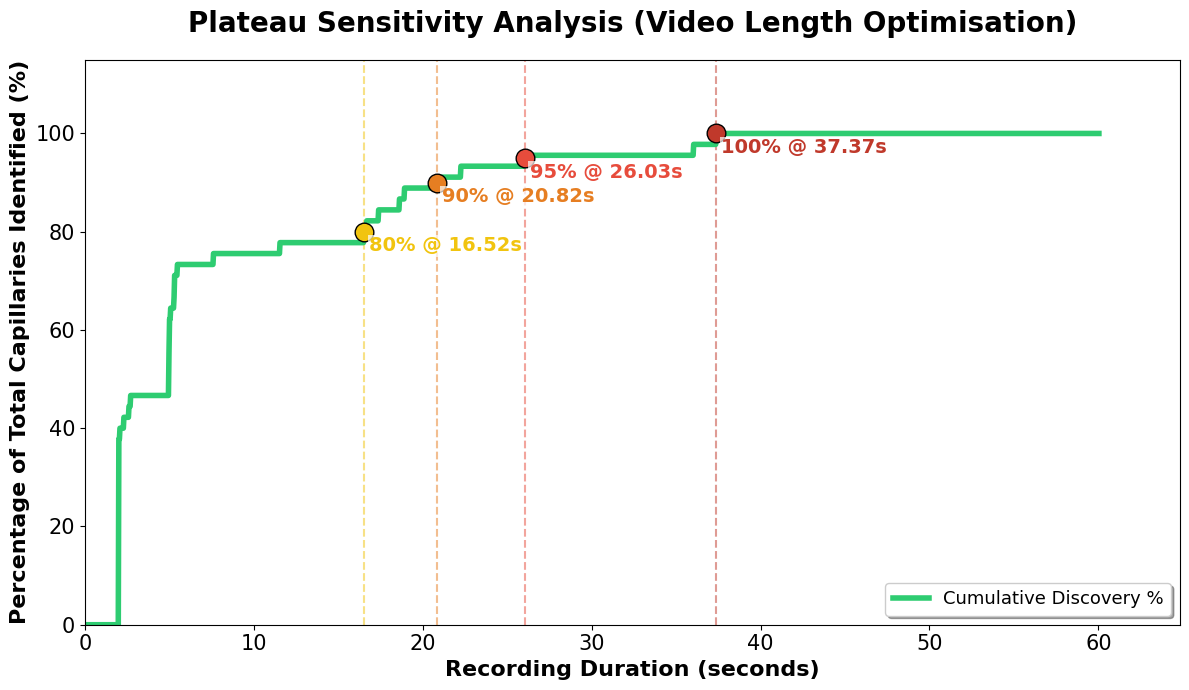

--- RESULTS ---
Total Unique Capillaries Found: 45
The system reached 80% completion at 16.52 seconds.
The system reached 90% completion at 20.82 seconds.
The system reached 95% completion at 26.03 seconds.
The system reached 100% completion at 37.37 seconds.


In [ ]:
#  Load and Process Data
# Reads the cumulative detection data and prepares the axes for plotting
df_plateau = pd.read_csv(out_csv)
final_total = df_plateau['cumulative'].iloc[-1] #the total number of capillaries found
time_s = df_plateau['frame'].to_numpy() / fps #converts frame numbers into actual time in seconds
cum_pct = (df_plateau['cumulative'].to_numpy() / final_total) * 100 #normalises discovery to a percentage

#  Threshold configurations
# Defines the milestones to identify how fast the system discovers capillaries
thresholds = [0.80, 0.90, 0.95, 1.00]
colors = ['#f1c40f', '#e67e22', '#e74c3c', '#c0392b']
milestones = {}

for th in thresholds:
  # Finds the first timestamp where the discovery percentage crosses the threshold
    idx = np.where(cum_pct >= (th * 100))[0]
    milestones[th] = time_s[idx[0]] if len(idx) > 0 else None

#  Plotting
plt.figure(figsize=(12, 7))

# The Main Curve: Visualises the discovery rate over time
plt.plot(time_s, cum_pct, color='#2ecc71', linewidth=4, label='Cumulative Discovery %', zorder=2)

#  Add Milestone Markers (High Visibility)
#Iterates through the milestones to draw callouts on the graph
for th, t, color in zip(thresholds, milestones.values(), colors):
    if t is not None:
        # Dashed vertical line
        plt.axvline(t, color=color, linestyle='--', alpha=0.5, zorder=1)

        # Larger scatter points
        plt.scatter(t, th*100, color=color, s=180, edgecolors='black', zorder=5)

        # Bolder, larger text labels with a white background 'bbox'
        plt.text(t + 0.3, (th*100) - 4, f'{int(th*100)}% @ {t:.2f}s',
                 color=color,
                 fontweight='extra bold',
                 fontsize=14,
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
                 zorder=6)

#  Styling and Formatting
plt.title("Plateau Sensitivity Analysis (Video Length Optimisation)", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Recording Duration (seconds)", fontsize=16, fontweight='bold')
plt.ylabel("Percentage of Total Capillaries Identified (%)", fontsize=16, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=15)

# Adjust limits and grid
plt.ylim(0, 115)
plt.xlim(0, time_s[-1] * 1.08) # Added slightly more padding for the 100% label
plt.legend(loc='lower right', fontsize=13, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('plateau_sensitivity_final.png', dpi=300)
plt.show()

#  Terminal Output
print(f"--- RESULTS ---")
print(f"Total Unique Capillaries Found: {int(final_total)}")
for th in thresholds:
    if milestones[th]:
        print(f"The system reached {int(th*100)}% completion at {milestones[th]:.2f} seconds.")

**Temporal Persistence and Tracking Stability Analysis**

* This block ranks capillary tracks by their duration across the video. Longer tracks indicate stable capillary identification, while shorter tracks may represent capillaries affected by movement, focus changes or brief visibility.

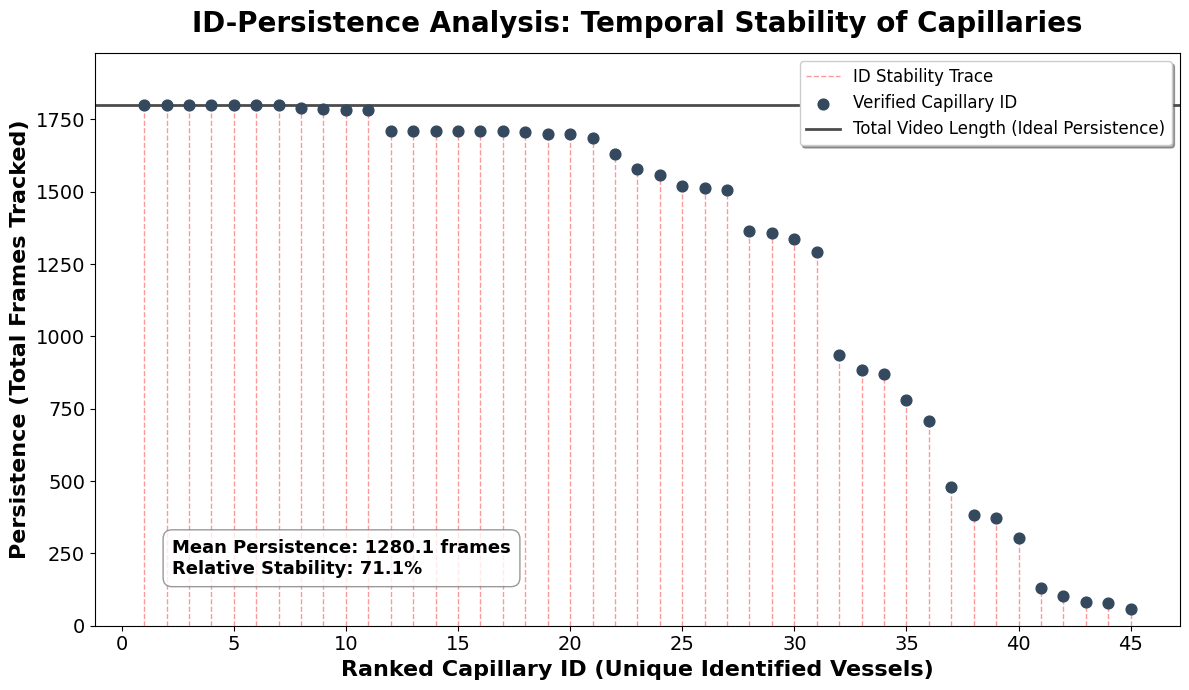

In [ ]:

# Prepare Data
# Calculates the lifespan (duration) of each capillary track in the video
lifespans = cap_table['last_frame'] - cap_table['first_frame']
total_video_frames = num_frames
# Ranks capillaries from longest-tracked to shortest-tracked for the visualisation
sorted_lifespans = np.sort(lifespans)[::-1]
ids = np.arange(1, len(sorted_lifespans) + 1)

plt.figure(figsize=(12, 7))

# Plot Vertical "Stem" Lines (The dashed lines from X-axis up)
plt.vlines(ids, ymin=0, ymax=sorted_lifespans, colors='red',
           linestyles='--', alpha=0.4, linewidth=1, label='ID Stability Trace')

# Plot the Data Points (The 'Cap' of each capillary)
# Marks the final persistence count for each unique capillary ID
plt.scatter(ids, sorted_lifespans, color='#34495e', s=60, zorder=3, label='Verified Capillary ID')

# Draw the Goal Line (Total Video Duration)
plt.axhline(y=total_video_frames, color='black', linewidth=2, linestyle='-',
            alpha=0.7, label='Total Video Length (Ideal Persistence)')

# Styling
plt.title("ID-Persistence Analysis: Temporal Stability of Capillaries", fontsize=20, fontweight='bold', pad=15)
plt.xlabel("Ranked Capillary ID (Unique Identified Vessels)", fontsize=16, fontweight="bold")
plt.ylabel("Persistence (Total Frames Tracked)", fontsize=16, fontweight='bold')
plt.xticks(np.arange(0, len(ids) + 1, 5))

# Enlarge the actual axis values (the numbers)
plt.tick_params(axis='both', which='major', labelsize=14)

# 6. Add stats text box
avg_p = (np.mean(lifespans) / total_video_frames) * 100
stats_text = f"Mean Persistence: {np.mean(lifespans):.1f} frames\nRelative Stability: {avg_p:.1f}%"

# Positioning the text box in the lower left area
plt.text(len(ids) * 0.05, total_video_frames * 0.1, stats_text,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'),
         fontsize=13, fontweight='bold')

# 7. Final Polish
plt.ylim(0, total_video_frames * 1.1) # Extra head room for the legend
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12)

plt.tight_layout()
plt.show()